In [1]:
import os
import time
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '../')))
import MGLensing
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.special import factorial
from scipy import integrate
from copy import deepcopy


# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

from matplotlib import rc
rc('text', usetex=True)

plt.rcParams["text.usetex"] = False
plt.rc('mathtext', fontset='stix')
plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=18)

2026-04-20 12:58:24.888315: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-20 12:58:25.460147: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 12:58:26.166756: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-20 12:58:26.167919: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-20 12:58:32.146578: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Co

euclidlib not installed! Euclid TR1 setup will not be available!
/home/c2042999/MGLensing/MGLensing


In [2]:
# Perform PCA with numpy.linalg.svd - find rotation matrix
def findPCA(M_data, B_data, L_ch_inv):
    Delta = np.array(np.matmul(L_ch_inv, (B_data - M_data).T).T)
    Usvd, s, vh = np.linalg.svd(Delta.T, full_matrices=True)
    Usvd = Usvd.T
    return Usvd, Delta


# PCA plots - see what the plots are like for fR/nDGP/GR

## Linear

In [ ]:
MGL_mu_lin = MGLensing.MGL("ini_files/pca/config_muSigma_lin_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_lin.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_lin.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_lin.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_lin.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_nDGP_nl = MGLensing.MGL("ini_files/pca/config_nDGP.yaml")
MGL_nDGP_linear = MGLensing.MGL("ini_files/pca/config_nDGP_lin.yaml")
MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
MGL_GR_linear = MGLensing.MGL("ini_files/pca/config_GR_lin.yaml")
MGL_fR_nl = MGLensing.MGL("ini_files/pca/config_fR.yaml")
MGL_fR_linear = MGLensing.MGL("ini_files/pca/config_fR_lin.yaml")
B_models = [
    MGL_nDGP_nl,
    MGL_fR_nl,
    MGL_GR_nl
]
M_models = [
    MGL_nDGP_linear,
    MGL_fR_linear,
    MGL_GR_linear
]

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

### COMBINE
# 1: find C_ell for non-linear matter power spectrum
B_data  = np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models])
# 2: find C_ell for linear matter power spectrum
M_data  = np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models])


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

Explained variance by each principal component:  [0.9786486  0.01604407 0.00530732]


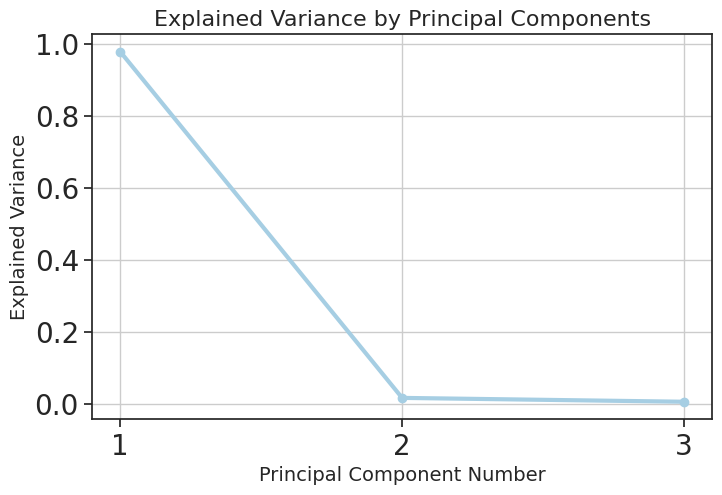

In [ ]:
Usvd, Delta = findPCA(M_data, B_data, L_ch_inv)

# Perform PCA with numpy.linalg.svd - find rotation matrix
def findPCA_and_explainedvariance(M_data, B_data, L_ch_inv):
    Delta = np.array(np.matmul(L_ch_inv, (B_data - M_data).T).T)
    Usvd, s, vh = np.linalg.svd(Delta.T, full_matrices=True)
    Usvd = Usvd.T
    # Calculate explained variance, variance_i = s_i/sum(s)
    explained_variance = s / np.sum(s)
    return Usvd, Delta, explained_variance

Usvd, Delta, explained_variance = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)

Usvd_GRfRnDGP, Delta_GRfRnDGP, explained_variance_GRfRnDGP = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)

print("Explained variance by each principal component: ", explained_variance)

#  plot of explained variance vs principal component number
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Principal Component Number', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Explained Variance by Principal Components', fontsize=16)
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()
plt.show()

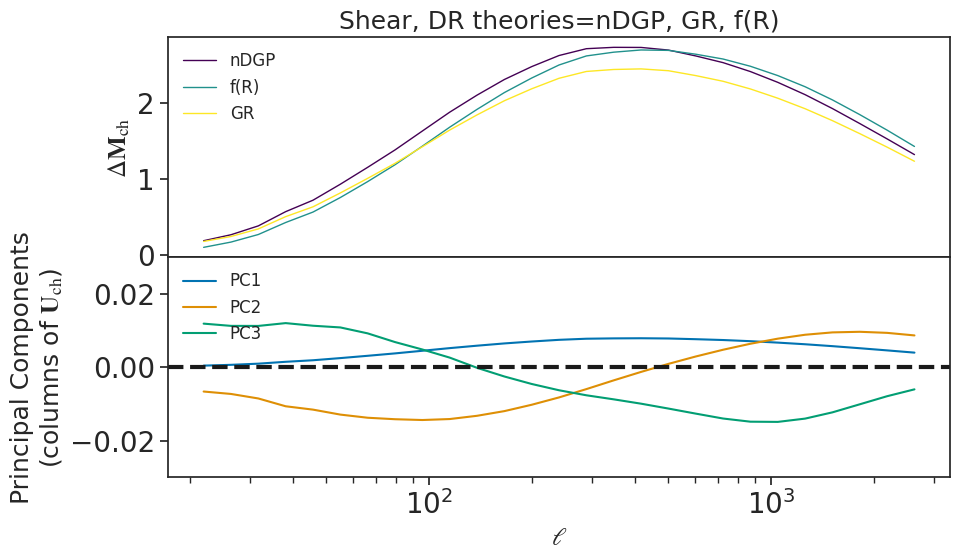

In [ ]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

# list 27 colors out of viridis color map, for the 27 combinations of q1q2q3 values
viridis = plt.cm.get_cmap('viridis', len(M_models))
colors1 = [viridis(i) for i in range(len(M_models))]

labels1 = ["nDGP", "f(R)", "GR"]
markers1 = ['o','D','P']
# list 27 colors out of colorblind color map, for the 27 combinations of q1q2q3 values

colors2 = [
    col[i] if i in range(len(M_models)) else (0.5, 0.5, 0.5, 1.0)
    for i in range(len(M_models))
]
labels2 = ['PC{}'.format(i+1) if i in range(len(M_models)) else None
    for i in range(len(M_models))
]

markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

# Interpolate and plot on each subplot
for i in range(len(M_models)):
    # Scatter points
    axs[0].plot(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i],  linewidth=1, label=labels1[i])
axs[0].set_title('Shear, DR theories=nDGP, GR, f(R)', fontsize=18)

for i in range(len(M_models)):
    if i in range(len(M_models)):
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
    else:
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1, alpha=0.2)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")
axs[1].set_ylim(-0.03, 0.03)
# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)
axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)
axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)
# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")
# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
# Display the plot
plt.show()


## Pseudo

In [ ]:
MGL_mu_pseudo = MGLensing.MGL("ini_files/pca/config_muSigma_pseudo_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_pseudo.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_pseudo.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_nDGP_nl = MGLensing.MGL("ini_files/pca/config_nDGP.yaml")
MGL_nDGP_pseudo = MGLensing.MGL("ini_files/pca/config_nDGP_pseudo.yaml")
MGL_fR_nl = MGLensing.MGL("ini_files/pca/config_fR.yaml")
MGL_fR_pseudo = MGLensing.MGL("ini_files/pca/config_fR_pseudo.yaml")
B_models = [
    MGL_nDGP_nl,
    MGL_fR_nl
]
M_models = [
    MGL_nDGP_pseudo,
    MGL_fR_pseudo
]

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

### COMBINE
# 1: find C_ell for non-linear matter power spectrum
B_data  = np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models])
# 2: find C_ell for linear matter power spectrum
M_data  = np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models])


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [ ]:
Usvd, Delta = findPCA(M_data, B_data, L_ch_inv)

Usvd_GRfRnDGP_pseudo, Delta_GRfRnDGP_pseudo, explained_variance_GRfRnDGP_pseudo = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)


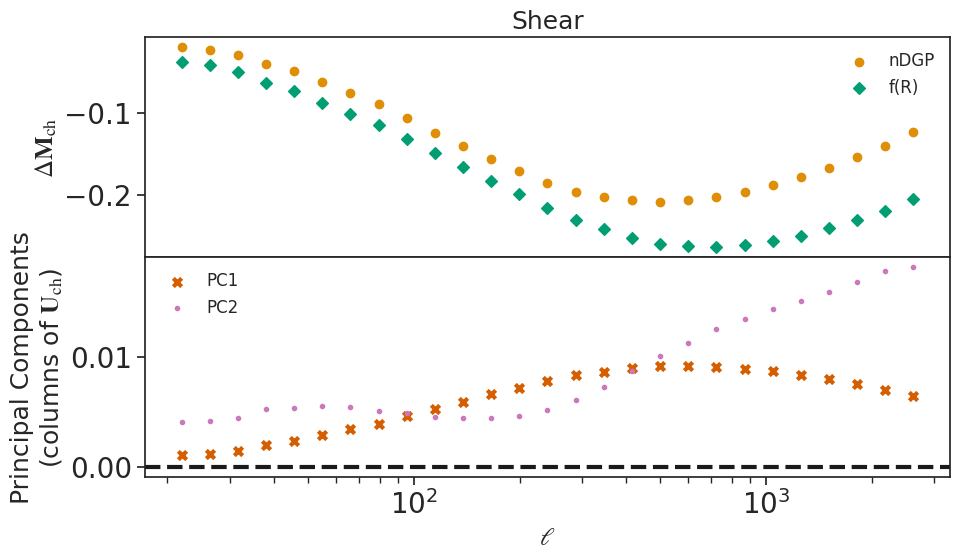

In [ ]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['nDGP','f(R)','GR']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_pseudo.Survey.ells_wl_max, MGL_mu_pseudo.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_pseudo.Survey.l_wl, MGL_mu_pseudo.Survey.l_gc, MGL_mu_pseudo.Survey.l_xc

#print(MGL_mu_pseudo.Survey.mask_ells_wl.shape,MGL_mu_pseudo.Survey.mask_ells_gc.shape, MGL_mu_pseudo.Survey.mask_ells_xc.shape)


# Interpolate and plot on each subplot
for i in range(len(B_models)):

    # Scatter points
    axs[0].scatter(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i], label=labels1[i], marker=markers1[i])

axs[0].set_title('Shear', fontsize=18)

for i in range(len(B_models)):

    # Scatter points
    axs[1].scatter(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], marker=markers2[i])

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()


## Check PC dependence on MG parameters - linear

In [ ]:
MGL_mu_lin = MGLensing.MGL("ini_files/pca/config_muSigma_lin_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_lin.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_lin.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_lin.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_lin.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_nDGP_nl = MGLensing.MGL("ini_files/pca/config_nDGP.yaml")
MGL_nDGP_linear = MGLensing.MGL("ini_files/pca/config_nDGP_lin.yaml")
MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
MGL_GR_linear = MGLensing.MGL("ini_files/pca/config_GR_lin.yaml")
MGL_fR_nl = MGLensing.MGL("ini_files/pca/config_fR.yaml")
MGL_fR_linear = MGLensing.MGL("ini_files/pca/config_fR_lin.yaml")
B_models = [
    MGL_nDGP_nl,
    MGL_fR_nl,
    MGL_GR_nl
]
M_models = [
    MGL_nDGP_linear,
    MGL_fR_linear,
    MGL_GR_linear
]

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [ ]:

fR0_vals = np.linspace(-6, -4, 12)
B_data_fR0 = []
M_data_fR0 = []

for fR0 in fR0_vals:
    param_dic_all["log10f_R0"] = fR0
    print(param_dic_all)
    B_data_fR0.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models]))
    M_data_fR0.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models]))

omegarc_vals = np.linspace(0.25, 1, 12)
B_data_omegarc = []
M_data_omegarc = []

for omegarc in omegarc_vals:
    param_dic_all["log10Omega_rc"] = np.log10(omegarc)
    print(param_dic_all)
    B_data_omegarc.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models]))
    M_data_omegarc.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models]))

{'Omega_m': 0.31892037, 'Ombh2': 0.0226738, 'h': 0.67567714, 'log10As': 3.02769177, 'ns': 0.95492059, 'log10f_R0': -6.0, 'a1_IA': 1.7180302, 'eta1_IA': -0.4060574, 'mu0': 0.0, 'sigma0': 0.0, 'q1': 0.0, 'Mnu': 0.0, 'w0': -1.0, 'wa': 0.0, 'gamma0': 0.8, 'gamma1': 0.0, 'q1_gamma': 0.0, 'log10Omega_rc': -0.60205999132, 'beta_IA': 0.0, 'b1_1': 1.562362, 'b1_2': 1.732963, 'b1_3': 1.913252, 'b1_4': 2.100644, 'b1_5': 2.29321, 'TCMB': 2.7255, 'nnu': 3.044, 'Omega_b': 0.04966447625406086, 'Omnuh2': 0.0, 'Omega_nu': 0.0, 'Omega_cb': 0.31892037, 'Omega_c': 0.26925589374593917, 'fb': 0.15572688647658617, 'As': 2.0649513710470528e-09}
{'Omega_m': 0.31892037, 'Ombh2': 0.0226738, 'h': 0.67567714, 'log10As': 3.02769177, 'ns': 0.95492059, 'log10f_R0': -5.818181818181818, 'a1_IA': 1.7180302, 'eta1_IA': -0.4060574, 'mu0': 0.0, 'sigma0': 0.0, 'q1': 0.0, 'Mnu': 0.0, 'w0': -1.0, 'wa': 0.0, 'gamma0': 0.8, 'gamma1': 0.0, 'q1_gamma': 0.0, 'log10Omega_rc': -0.60205999132, 'beta_IA': 0.0, 'b1_1': 1.562362, 'b1_2'

In [ ]:

Usvd_fR0 = []
Delta_fR0 = []
Usvd_omegarc = []
Delta_omegarc = []
for i in range(len(B_models)):
    Usvd_fR0.append([])
    Delta_fR0.append([])
    Usvd_omegarc.append([])
    Delta_omegarc.append([])
    for j in range(len(fR0_vals)):
        Usvd_fR0[i].append(findPCA(M_data_fR0[j], B_data_fR0[j], L_ch_inv)[0][i])
        Delta_fR0[i].append(findPCA(M_data_fR0[j], B_data_fR0[j], L_ch_inv)[1][i])
    for j in range(len(omegarc_vals)):
        Usvd_omegarc[i].append(findPCA(M_data_omegarc[j], B_data_omegarc[j], L_ch_inv)[0][i])
        Delta_omegarc[i].append(findPCA(M_data_omegarc[j], B_data_omegarc[j], L_ch_inv)[1][i])

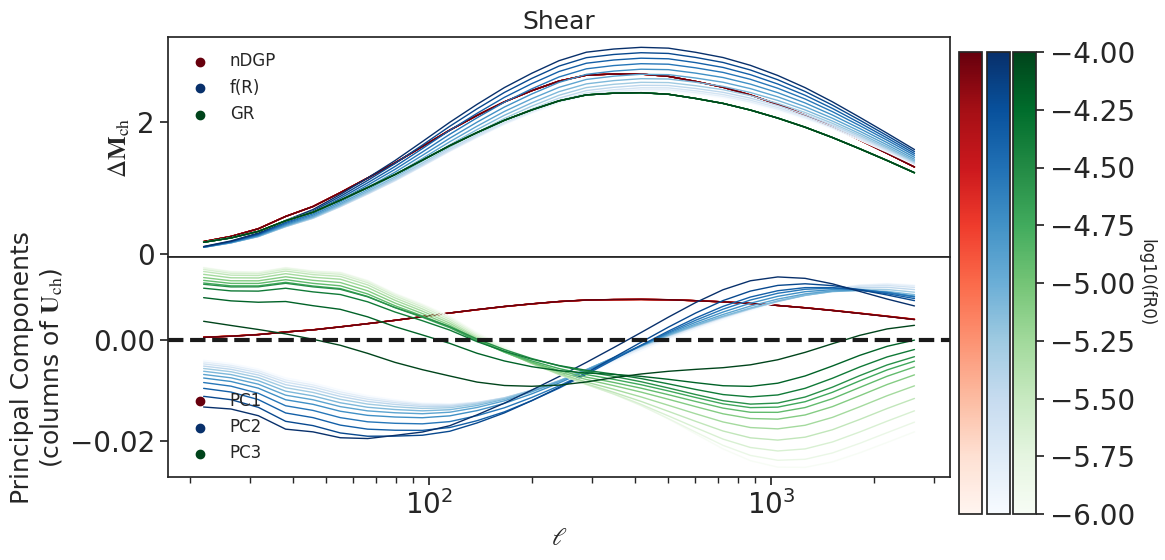

In [12]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['nDGP','f(R)','GR']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

#print(MGL_mu_lin.Survey.mask_ells_wl.shape,MGL_mu_lin.Survey.mask_ells_gc.shape, MGL_mu_lin.Survey.mask_ells_xc.shape)


# plot points, with 3 different color bars (varying with fR0) depending on B_model
colorbar_nDGP = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
colorbar_fR = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
colorbar_GR = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))

colorbars = [colorbar_nDGP, colorbar_fR, colorbar_GR]

# add color bar in gray scale
colorbar_grayscale = plt.cm.ScalarMappable(cmap='gray', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
for i in range(len(B_models)):
    # add to whole plot, not just subplot. Add the plot to the right by 2 cms
    cbar = plt.colorbar(colorbars[i], pad=0.0, ax=axs, location='right', anchor=(2.1+[0,2.15,5][i],0.5))
    # remove ticks from color bar
    if i != len(B_models) - 1:
        cbar.set_ticks([])
cbar.set_label('log10(fR0)', rotation=270, labelpad=15, fontsize=12)

# add label for "nDGP", "f(R)", "GR" being red, blue, green respectively in plot
axs[0].scatter([], [], color=colorbar_nDGP.to_rgba(fR0_vals[-1]), label='nDGP')
axs[0].scatter([], [], color=colorbar_fR.to_rgba(fR0_vals[-1]), label='f(R)')
axs[0].scatter([], [], color=colorbar_GR.to_rgba(fR0_vals[-1]), label='GR')
axs[0].legend(fontsize=12, frameon=False, loc='upper right')
axs[1].scatter([], [], color=colorbar_nDGP.to_rgba(fR0_vals[-1]), label='PC1')
axs[1].scatter([], [], color=colorbar_fR.to_rgba(fR0_vals[-1]), label='PC2')
axs[1].scatter([], [], color=colorbar_GR.to_rgba(fR0_vals[-1]), label='PC3')
axs[1].legend(fontsize=12, frameon=False, loc='upper right')

# Interpolate and plot on each subplot
for i in range(len(B_models)):
    for j in range(len(fR0_vals)):
        
        axs[0].plot(l_wl[:ells_wl_bins[0]], Delta_fR0[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(fR0_vals[j]), linewidth=1)
        # Plot Delta_fR0[i][j][:ells_wl_bins[0]]
axs[0].set_title('Shear', fontsize=18)

for i in range(len(B_models)):
    for j in range(len(fR0_vals)):
        
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd_fR0[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(fR0_vals[j]), linewidth=1)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()


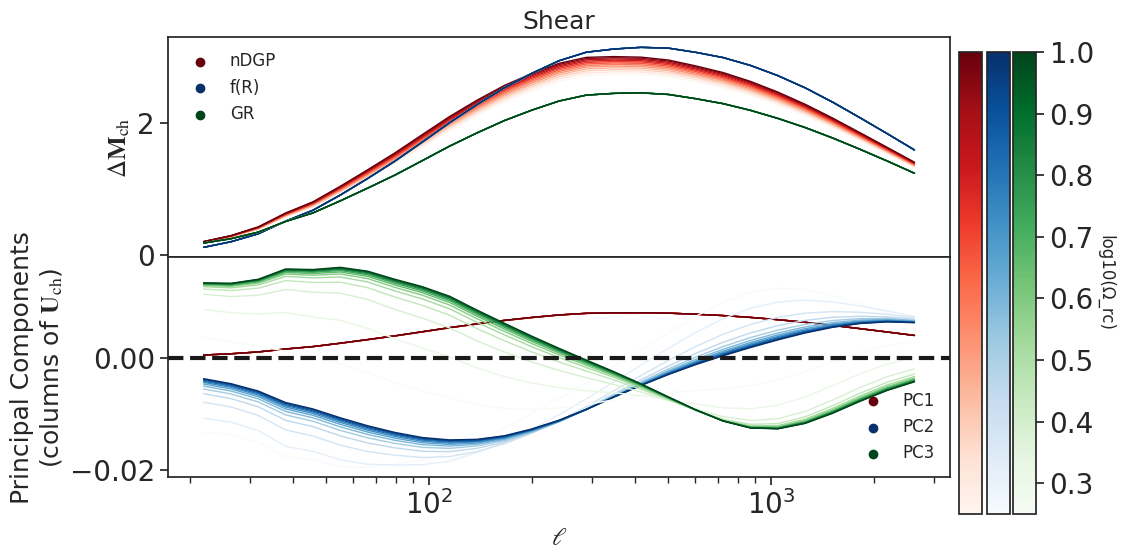

In [13]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['nDGP','f(R)','GR']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

#print(MGL_mu_lin.Survey.mask_ells_wl.shape,MGL_mu_lin.Survey.mask_ells_gc.shape, MGL_mu_lin.Survey.mask_ells_xc.shape)


# plot points, with 3 different color bars (varying with fR0) depending on B_model
colorbar_nDGP = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
colorbar_fR = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
colorbar_GR = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))

colorbars = [colorbar_nDGP, colorbar_fR, colorbar_GR]

# add color bar in gray scale
colorbar_grayscale = plt.cm.ScalarMappable(cmap='gray', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
for i in range(len(B_models)):
    # add to whole plot, not just subplot. Add the plot to the right by 2 cms
    cbar = plt.colorbar(colorbars[i], pad=0.0, ax=axs, location='right', anchor=(2.1+[0,2.15,5][i],0.5))
    # remove ticks from color bar
    if i != len(B_models) - 1:
        cbar.set_ticks([])
cbar.set_label('log10(Ω_rc)', rotation=270, labelpad=15, fontsize=12)

# add label for "nDGP", "f(R)", "GR" being red, blue, green respectively in plot
axs[0].scatter([], [], color=colorbar_nDGP.to_rgba(omegarc_vals[-1]), label='nDGP')
axs[0].scatter([], [], color=colorbar_fR.to_rgba(omegarc_vals[-1]), label='f(R)')
axs[0].scatter([], [], color=colorbar_GR.to_rgba(omegarc_vals[-1]), label='GR')
axs[0].legend(fontsize=12, frameon=False, loc='upper right')
axs[1].scatter([], [], color=colorbar_nDGP.to_rgba(omegarc_vals[-1]), label='PC1')
axs[1].scatter([], [], color=colorbar_fR.to_rgba(omegarc_vals[-1]), label='PC2')
axs[1].scatter([], [], color=colorbar_GR.to_rgba(omegarc_vals[-1]), label='PC3')
axs[1].legend(fontsize=12, frameon=False, loc='upper right')

# Interpolate and plot on each subplot
for i in range(len(B_models)):
    for j in range(len(omegarc_vals)):
        
        axs[0].plot(l_wl[:ells_wl_bins[0]], Delta_omegarc[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(omegarc_vals[j]), linewidth=1)
        # Plot Delta_omegarc[i][j][:ells_wl_bins[0]]
axs[0].set_title('Shear', fontsize=18)

for i in range(len(B_models)):
    for j in range(len(omegarc_vals)):
        
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd_omegarc[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(omegarc_vals[j]), linewidth=1)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()


## Check PC dependence on MG parameters - pseudo

In [14]:
MGL_mu_pseudo = MGLensing.MGL("ini_files/pca/config_muSigma_pseudo_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_pseudo.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_pseudo.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_nDGP_nl = MGLensing.MGL("ini_files/pca/config_nDGP.yaml")
MGL_nDGP_pseudo = MGLensing.MGL("ini_files/pca/config_nDGP_pseudo.yaml")
MGL_fR_nl = MGLensing.MGL("ini_files/pca/config_fR.yaml")
MGL_fR_pseudo = MGLensing.MGL("ini_files/pca/config_fR_pseudo.yaml")
B_models = [
    MGL_nDGP_nl,
    MGL_fR_nl
]
M_models = [
    MGL_nDGP_pseudo,
    MGL_fR_pseudo
]

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [15]:

fR0_vals = np.linspace(-6, -4, 8)
B_data_fR0 = []
M_data_fR0 = []

for fR0 in fR0_vals:
    param_dic_all["log10f_R0"] = fR0
    print(param_dic_all)
    B_data_fR0.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models]))
    M_data_fR0.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models]))

omegarc_vals = np.linspace(0.25, 1, 8)
B_data_omegarc = []
M_data_omegarc = []

for omegarc in omegarc_vals:
    param_dic_all["log10Omega_rc"] = np.log10(omegarc)
    print(param_dic_all)
    B_data_omegarc.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in B_models]))
    M_data_omegarc.append(np.array([m.Like.compute_data_vector(param_dic_all) for m in M_models]))

{'Omega_m': 0.31892037, 'Ombh2': 0.0226738, 'h': 0.67567714, 'log10As': 3.02769177, 'ns': 0.95492059, 'log10f_R0': -6.0, 'a1_IA': 1.7180302, 'eta1_IA': -0.4060574, 'mu0': 0.0, 'sigma0': 0.0, 'q1': 0.0, 'Mnu': 0.0, 'w0': -1.0, 'wa': 0.0, 'gamma0': 0.8, 'gamma1': 0.0, 'q1_gamma': 0.0, 'log10Omega_rc': -0.60205999132, 'beta_IA': 0.0, 'b1_1': 1.562362, 'b1_2': 1.732963, 'b1_3': 1.913252, 'b1_4': 2.100644, 'b1_5': 2.29321, 'TCMB': 2.7255, 'nnu': 3.044, 'Omega_b': 0.04966447625406086, 'Omnuh2': 0.0, 'Omega_nu': 0.0, 'Omega_cb': 0.31892037, 'Omega_c': 0.26925589374593917, 'fb': 0.15572688647658617, 'As': 2.0649513710470528e-09}
{'Omega_m': 0.31892037, 'Ombh2': 0.0226738, 'h': 0.67567714, 'log10As': 3.02769177, 'ns': 0.95492059, 'log10f_R0': -5.714285714285714, 'a1_IA': 1.7180302, 'eta1_IA': -0.4060574, 'mu0': 0.0, 'sigma0': 0.0, 'q1': 0.0, 'Mnu': 0.0, 'w0': -1.0, 'wa': 0.0, 'gamma0': 0.8, 'gamma1': 0.0, 'q1_gamma': 0.0, 'log10Omega_rc': -0.60205999132, 'beta_IA': 0.0, 'b1_1': 1.562362, 'b1_2'

In [16]:

Usvd_fR0 = []
Delta_fR0 = []
Usvd_omegarc = []
Delta_omegarc = []
for i in range(len(B_models)):
    Usvd_fR0.append([])
    Delta_fR0.append([])
    Usvd_omegarc.append([])
    Delta_omegarc.append([])
    for j in range(len(fR0_vals)):
        Usvd_fR0[i].append(findPCA(M_data_fR0[j], B_data_fR0[j], L_ch_inv)[0][i])
        Delta_fR0[i].append(findPCA(M_data_fR0[j], B_data_fR0[j], L_ch_inv)[1][i])
    for j in range(len(omegarc_vals)):
        Usvd_omegarc[i].append(findPCA(M_data_omegarc[j], B_data_omegarc[j], L_ch_inv)[0][i])
        Delta_omegarc[i].append(findPCA(M_data_omegarc[j], B_data_omegarc[j], L_ch_inv)[1][i])

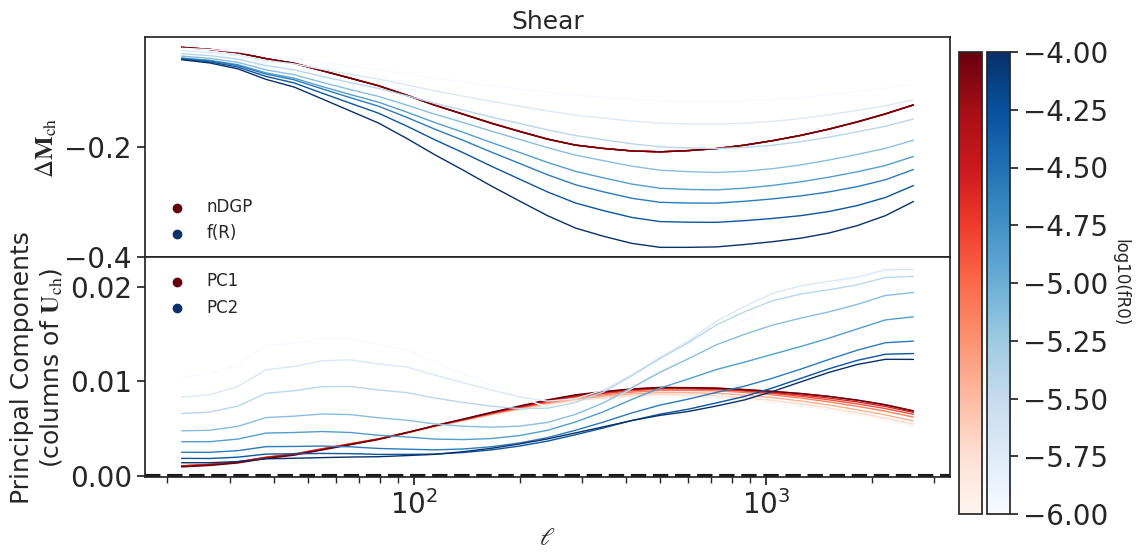

In [17]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['nDGP','f(R)','GR']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

#print(MGL_mu_lin.Survey.mask_ells_wl.shape,MGL_mu_lin.Survey.mask_ells_gc.shape, MGL_mu_lin.Survey.mask_ells_xc.shape)


# plot points, with 3 different color bars (varying with fR0) depending on B_model
colorbar_nDGP = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
colorbar_fR = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
colorbar_GR = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))

colorbars = [colorbar_nDGP, colorbar_fR, colorbar_GR]

# add color bar in gray scale
colorbar_grayscale = plt.cm.ScalarMappable(cmap='gray', norm=plt.Normalize(vmin=fR0_vals[0], vmax=fR0_vals[-1]))
for i in range(len(B_models)):
    # add to whole plot, not just subplot. Add the plot to the right by 2 cms
    cbar = plt.colorbar(colorbars[i], pad=0.0, ax=axs, location='right', anchor=(2.1+[0,2.15,5][i],0.5))
    # remove ticks from color bar
    if i != len(B_models) - 1:
        cbar.set_ticks([])
cbar.set_label('log10(fR0)', rotation=270, labelpad=15, fontsize=12)

# add label for "nDGP", "f(R)", "GR" being red, blue, green respectively in plot
axs[0].scatter([], [], color=colorbar_nDGP.to_rgba(fR0_vals[-1]), label='nDGP')
axs[0].scatter([], [], color=colorbar_fR.to_rgba(fR0_vals[-1]), label='f(R)')
#axs[0].scatter([], [], color=colorbar_GR.to_rgba(fR0_vals[-1]), label='GR')
axs[0].legend(fontsize=12, frameon=False, loc='upper right')
axs[1].scatter([], [], color=colorbar_nDGP.to_rgba(fR0_vals[-1]), label='PC1')
axs[1].scatter([], [], color=colorbar_fR.to_rgba(fR0_vals[-1]), label='PC2')
#axs[1].scatter([], [], color=colorbar_GR.to_rgba(fR0_vals[-1]), label='PC3')
axs[1].legend(fontsize=12, frameon=False, loc='upper right')

# Interpolate and plot on each subplot
for i in range(len(B_models)):
    for j in range(len(fR0_vals)):
        
        axs[0].plot(l_wl[:ells_wl_bins[0]], Delta_fR0[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(fR0_vals[j]), linewidth=1)
        # Plot Delta_fR0[i][j][:ells_wl_bins[0]]
axs[0].set_title('Shear', fontsize=18)

for i in range(len(B_models)):
    for j in range(len(fR0_vals)):
        
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd_fR0[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(fR0_vals[j]), linewidth=1)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()

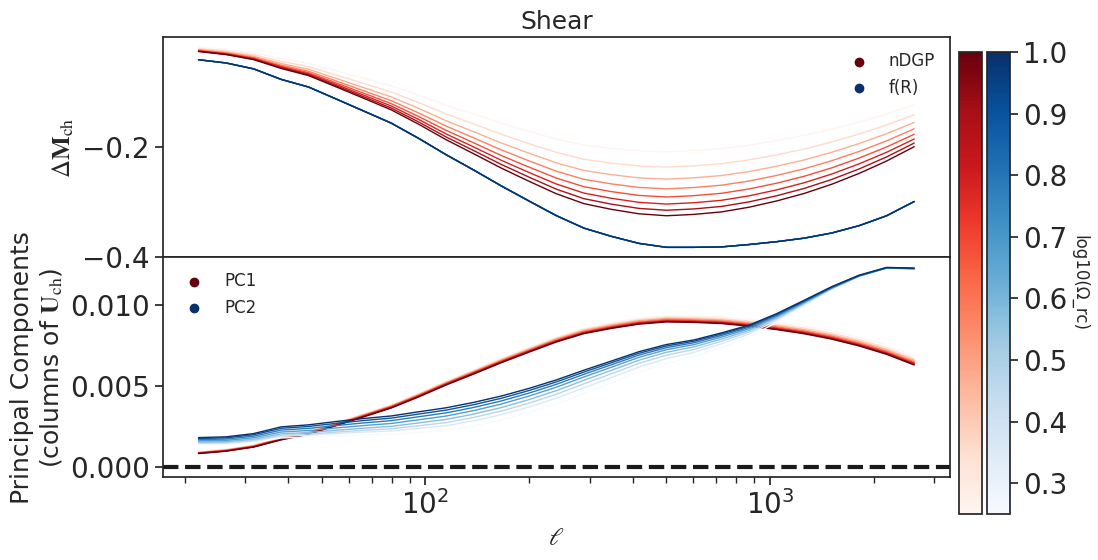

In [18]:

col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['nDGP','f(R)','GR']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

#print(MGL_mu_lin.Survey.mask_ells_wl.shape,MGL_mu_lin.Survey.mask_ells_gc.shape, MGL_mu_lin.Survey.mask_ells_xc.shape)


# plot points, with 3 different color bars (varying with fR0) depending on B_model
colorbar_nDGP = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
colorbar_fR = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
colorbar_GR = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))

colorbars = [colorbar_nDGP, colorbar_fR, colorbar_GR]

# add color bar in gray scale
colorbar_grayscale = plt.cm.ScalarMappable(cmap='gray', norm=plt.Normalize(vmin=omegarc_vals[0], vmax=omegarc_vals[-1]))
for i in range(len(B_models)):
    # add to whole plot, not just subplot. Add the plot to the right by 2 cms
    cbar = plt.colorbar(colorbars[i], pad=0.0, ax=axs, location='right', anchor=(2.1+[0,2.15,5][i],0.5))
    # remove ticks from color bar
    if i != len(B_models) - 1:
        cbar.set_ticks([])
cbar.set_label('log10(Ω_rc)', rotation=270, labelpad=15, fontsize=12)

# add label for "nDGP", "f(R)", "GR" being red, blue, green respectively in plot
axs[0].scatter([], [], color=colorbar_nDGP.to_rgba(omegarc_vals[-1]), label='nDGP')
axs[0].scatter([], [], color=colorbar_fR.to_rgba(omegarc_vals[-1]), label='f(R)')
#axs[0].scatter([], [], color=colorbar_GR.to_rgba(omegarc_vals[-1]), label='GR')
axs[0].legend(fontsize=12, frameon=False, loc='upper right')
axs[1].scatter([], [], color=colorbar_nDGP.to_rgba(omegarc_vals[-1]), label='PC1')
axs[1].scatter([], [], color=colorbar_fR.to_rgba(omegarc_vals[-1]), label='PC2')
#axs[1].scatter([], [], color=colorbar_GR.to_rgba(omegarc_vals[-1]), label='PC3')
axs[1].legend(fontsize=12, frameon=False, loc='upper right')

# Interpolate and plot on each subplot
for i in range(len(B_models)):
    for j in range(len(omegarc_vals)):
        
        axs[0].plot(l_wl[:ells_wl_bins[0]], Delta_omegarc[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(omegarc_vals[j]), linewidth=1)
        # Plot Delta_omegarc[i][j][:ells_wl_bins[0]]
axs[0].set_title('Shear', fontsize=18)

for i in range(len(B_models)):
    for j in range(len(omegarc_vals)):
        
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd_omegarc[i][j][:ells_wl_bins[0]], color=colorbars[i].to_rgba(omegarc_vals[j]), linewidth=1)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()

# PCA plots - see what plots are like for q1/q2/q3

## Linear

In [19]:
MGL_mu_lin = MGLensing.MGL("ini_files/pca/config_muSigma_lin_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_lin.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_lin.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_lin.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_lin.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_q1q2q3_nl = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3.yaml")
MGL_q1q2q3_linear = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3_lin.yaml")

Model_q1q2q3_values_list = [(2,0,0), (0,2.0,0), (0,0,2.0)]


# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

# define params for analysis below
param_dic_all["mu0"] = 0.2
param_dic_all["Sigma0"] = 0.0

#q1: 0.2 :: 2.0
#q2: 0 :: 1.0
#q3: 0 :: 3

param_dic_list = []
for q1q2q3 in Model_q1q2q3_values_list:
    param_dic_list.append(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})
### COMBINE
# 1: find C_ell for non-linear matter power spectrum
B_data  = np.array([MGL_q1q2q3_nl.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])
# 2: find C_ell for linear matter power spectrum
M_data  = np.array([MGL_q1q2q3_linear.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [20]:
Usvd, Delta = findPCA(M_data, B_data, L_ch_inv)

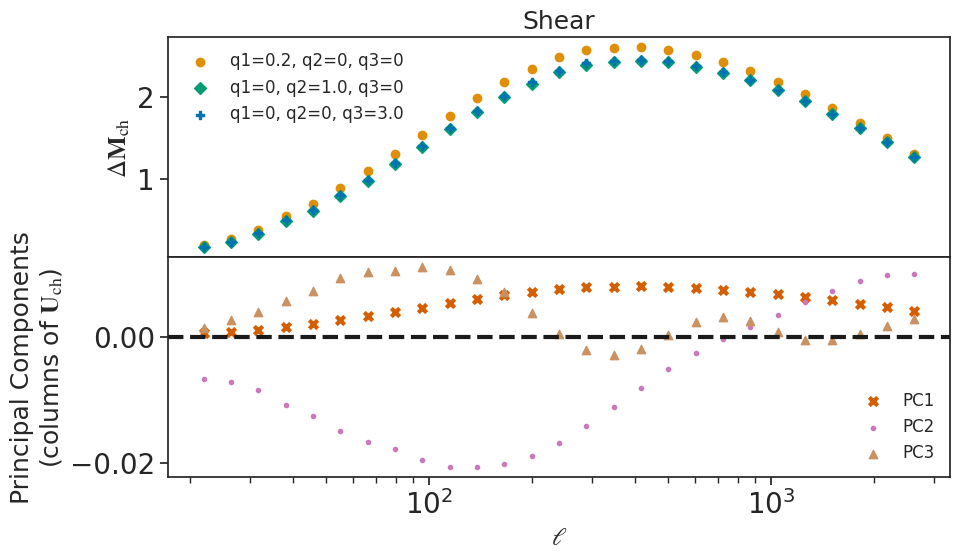

In [21]:
col = sns.color_palette("colorblind", 6)
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

colors1 = [col[1],col[2],col[0]]
labels1 = ['q1=0.2, q2=0, q3=0', 'q1=0, q2=1.0, q3=0', 'q1=0, q2=0, q3=3.0']
markers1 = ['o','D','P']

colors2 = [col[3],col[4],col[5]]
labels2 = ['PC1','PC2','PC3']
markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

#print(MGL_mu_lin.Survey.mask_ells_wl.shape,MGL_mu_lin.Survey.mask_ells_gc.shape, MGL_mu_lin.Survey.mask_ells_xc.shape)


# Interpolate and plot on each subplot
for i in range(len(Model_q1q2q3_values_list)):

    # Scatter points
    axs[0].scatter(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i], label=labels1[i], marker=markers1[i])

axs[0].set_title('Shear', fontsize=18)

for i in range(len(Model_q1q2q3_values_list)):

    # Scatter points
    axs[1].scatter(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], marker=markers2[i])

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)


axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)


axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)

# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)

# Display the plot
plt.show()


## Linear, extended

In [22]:
MGL_mu_lin = MGLensing.MGL("ini_files/pca/config_muSigma_lin_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_lin.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_lin.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_lin.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_lin.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_q1q2q3_nl = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3.yaml")
MGL_q1q2q3_linear = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3_lin.yaml")

# find range of q1q2q3 values

q1_arr = np.linspace(-2, 2,3)
q2_arr = np.linspace(-2,2, 3)
q3_arr = np.linspace(-2,2, 3)

# find all combinations of q1q2q3 values in the ranges above, and store in list
Model_q1q2q3_values_list = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

Model_q1q2q3_values_list = [(-2,0,0), (0,-2,0), (0,0,-2), (2,0,0), (0,2,0), (0,0,2)]
print(Model_q1q2q3_values_list)
print("q1q2q3 combinations length: ", len(Model_q1q2q3_values_list))

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

# define params for analysis below
param_dic_all["mu0"] = 0.2
param_dic_all["Sigma0"] = 0.0


param_dic_list = []
for q1q2q3 in Model_q1q2q3_values_list:
    param_dic_list.append(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})
    _, status = MGL_q1q2q3_nl.Like.Theo.check_pars(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})

### COMBINE
# 1: find C_ell for non-linear matter power spectrum
B_data  = np.array([MGL_q1q2q3_nl.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])
# 2: find C_ell for linear matter power spectrum
M_data  = np.array([MGL_q1q2q3_linear.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])


Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

Explained variance by each principal component:  [9.91521884e-01 5.80885529e-03 1.94516433e-03 3.44095871e-04
 2.66790193e-04 1.13210663e-04]
(array([0, 1, 2]),)


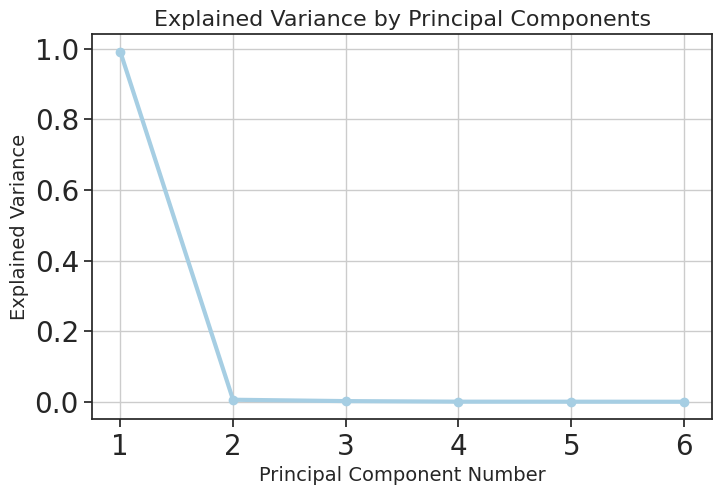

In [23]:
# Perform PCA with numpy.linalg.svd - find rotation matrix
def findPCA_and_explainedvariance(M_data, B_data, L_ch_inv):
    Delta = np.array(np.matmul(L_ch_inv, (B_data - M_data).T).T)
    Usvd, s, vh = np.linalg.svd(Delta.T, full_matrices=True)
    Usvd = Usvd.T
    # Calculate explained variance, variance_i = s_i/sum(s)
    explained_variance = s / np.sum(s)
    return Usvd, Delta, explained_variance

Usvd, Delta, explained_variance = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)

print("Explained variance by each principal component: ", explained_variance)

# keep PCs that explain more than 99.9% variance
pc_indices = np.where(explained_variance > 0.001)
print(pc_indices)

#  plot of explained variance vs principal component number
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xlabel('Principal Component Number', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Explained Variance by Principal Components', fontsize=16)
plt.xticks(range(1, len(explained_variance) + 1))
plt.grid()
plt.show()

Plot for basis Model set:  [(-2, 0, 0), (0, -2, 0), (0, 0, -2), (2, 0, 0), (0, 2, 0), (0, 0, 2)]
Number of models:  6


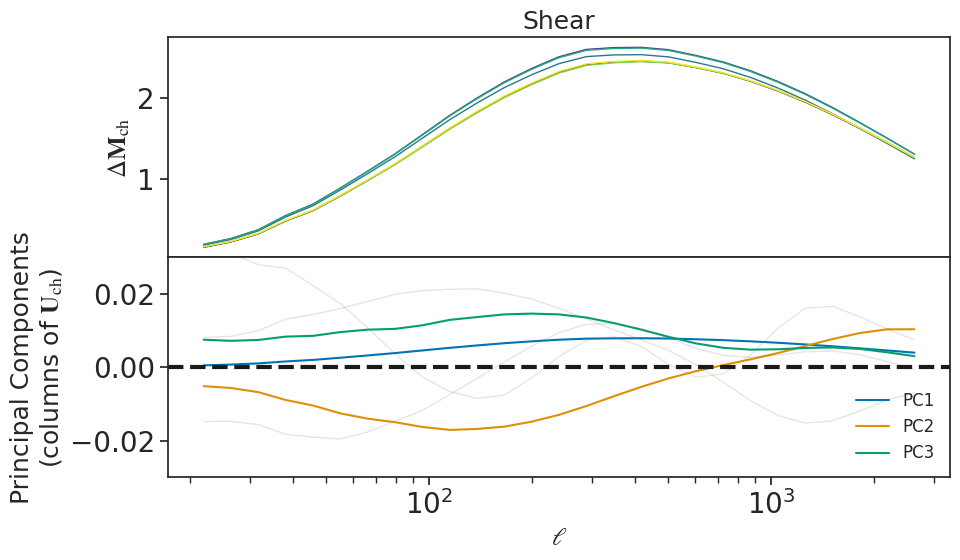

In [24]:
print("Plot for basis Model set: ", Model_q1q2q3_values_list)
print("Number of models: ", len(Model_q1q2q3_values_list))
col = sns.color_palette("colorblind", len(pc_indices[0]))
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

# list 27 colors out of viridis color map, for the 27 combinations of q1q2q3 values
viridis = plt.cm.get_cmap('viridis', len(Model_q1q2q3_values_list))
colors1 = [viridis(i) for i in range(len(Model_q1q2q3_values_list))]

labels1 = [r'q1,q2,q3=({:.1f}, {:.1f}, {:.1f})'.format(q1, q2, q3) for q1, q2, q3 in Model_q1q2q3_values_list]
markers1 = ['o','D','P']
# list 27 colors out of colorblind color map, for the 27 combinations of q1q2q3 values

colors2 = [
    col[i] if i in (pc_indices[0]) else (0.5, 0.5, 0.5, 1.0)
    for i in range(len(Model_q1q2q3_values_list))
]
labels2 = ['PC{}'.format(i+1) if i in (pc_indices[0]) else None
    for i in range(len(Model_q1q2q3_values_list))
]

markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

# Interpolate and plot on each subplot
for i in range(len(Model_q1q2q3_values_list)):
    # Scatter points
    axs[0].plot(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i],  linewidth=1)
axs[0].set_title('Shear', fontsize=18)

for i in range(len(Model_q1q2q3_values_list)):
    if i in pc_indices[0]:
        if i == 2:
            axs[1].plot(l_wl[:ells_wl_bins[0]], Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
        else:
            axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
    else:
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1, alpha=0.2)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")
axs[1].set_ylim(-0.03, 0.03)
# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)
axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)
axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)
# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")
# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
# Display the plot
plt.show()


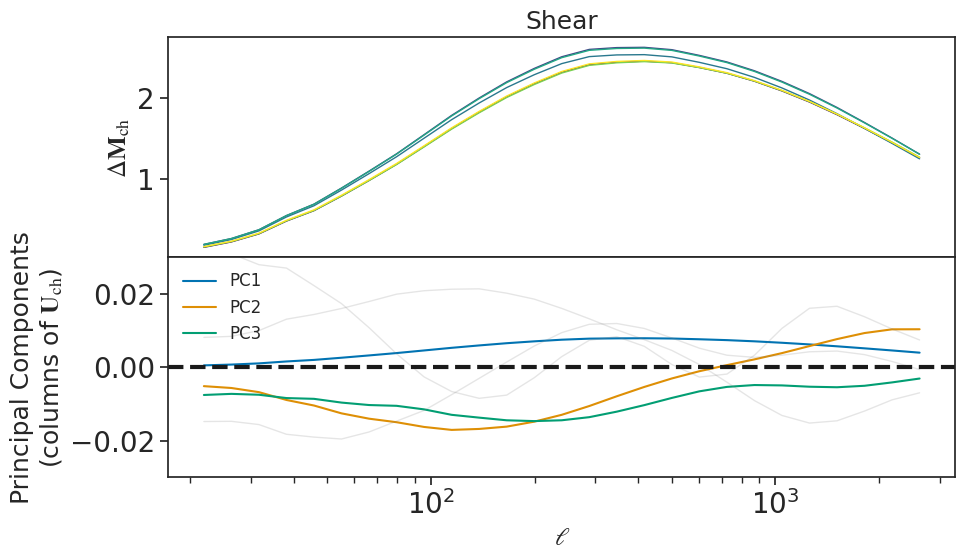

6


In [25]:
col = sns.color_palette("colorblind", len(pc_indices[0]))
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

# list 27 colors out of viridis color map, for the 27 combinations of q1q2q3 values
viridis = plt.cm.get_cmap('viridis', len(Model_q1q2q3_values_list))
colors1 = [viridis(i) for i in range(len(Model_q1q2q3_values_list))]

labels1 = [r'q1,q2,q3=({:.1f}, {:.1f}, {:.1f})'.format(q1, q2, q3) for q1, q2, q3 in Model_q1q2q3_values_list]
markers1 = ['o','D','P']
# list 27 colors out of colorblind color map, for the 27 combinations of q1q2q3 values

colors2 = [
    col[i] if i in (pc_indices[0]) else (0.5, 0.5, 0.5, 1.0)
    for i in range(len(Model_q1q2q3_values_list))
]
labels2 = ['PC{}'.format(i+1) if i in (pc_indices[0]) else None
    for i in range(len(Model_q1q2q3_values_list))
]

markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

# Interpolate and plot on each subplot
for i in range(len(Model_q1q2q3_values_list)):
    # Scatter points
    axs[0].plot(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i],  linewidth=1)
axs[0].set_title('Shear', fontsize=18)

for i in range(len(Model_q1q2q3_values_list)):
    if i in pc_indices[0]:
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
    else:
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1, alpha=0.2)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)
axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)
axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)
# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")
# Adjust layout to prevent overlap
plt.tight_layout()
axs[1].set_ylim(-0.03, 0.03)

plt.subplots_adjust(wspace=0, hspace=0)
# Display the plot
plt.show()
print(len(Model_q1q2q3_values_list))

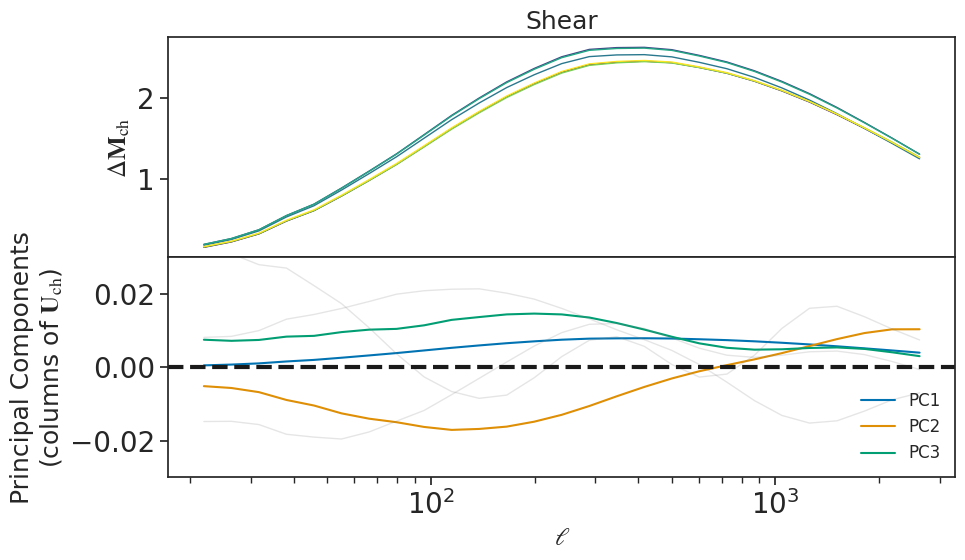

6


In [26]:
col = sns.color_palette("colorblind", len(pc_indices[0]))
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

# list 27 colors out of viridis color map, for the 27 combinations of q1q2q3 values
viridis = plt.cm.get_cmap('viridis', len(Model_q1q2q3_values_list))
colors1 = [viridis(i) for i in range(len(Model_q1q2q3_values_list))]

labels1 = [r'q1,q2,q3=({:.1f}, {:.1f}, {:.1f})'.format(q1, q2, q3) for q1, q2, q3 in Model_q1q2q3_values_list]
markers1 = ['o','D','P']
# list 27 colors out of colorblind color map, for the 27 combinations of q1q2q3 values

colors2 = [
    col[i] if i in (pc_indices[0]) else (0.5, 0.5, 0.5, 1.0)
    for i in range(len(Model_q1q2q3_values_list))
]
labels2 = ['PC{}'.format(i+1) if i in (pc_indices[0]) else None
    for i in range(len(Model_q1q2q3_values_list))
]

markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

# Interpolate and plot on each subplot
for i in range(len(Model_q1q2q3_values_list)):
    # Scatter points
    axs[0].plot(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i],  linewidth=1)
axs[0].set_title('Shear', fontsize=18)

for i in range(len(Model_q1q2q3_values_list)):
    if i in pc_indices[0]:
        if i == 2:
            axs[1].plot(l_wl[:ells_wl_bins[0]], Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
        else:
            # Scatter points
            axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
    else:
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1, alpha=0.2)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)
axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)
axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)
# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")
# Adjust layout to prevent overlap
plt.tight_layout()
axs[1].set_ylim(-0.03, 0.03)

plt.subplots_adjust(wspace=0, hspace=0)
# Display the plot
plt.show()
print(len(Model_q1q2q3_values_list))

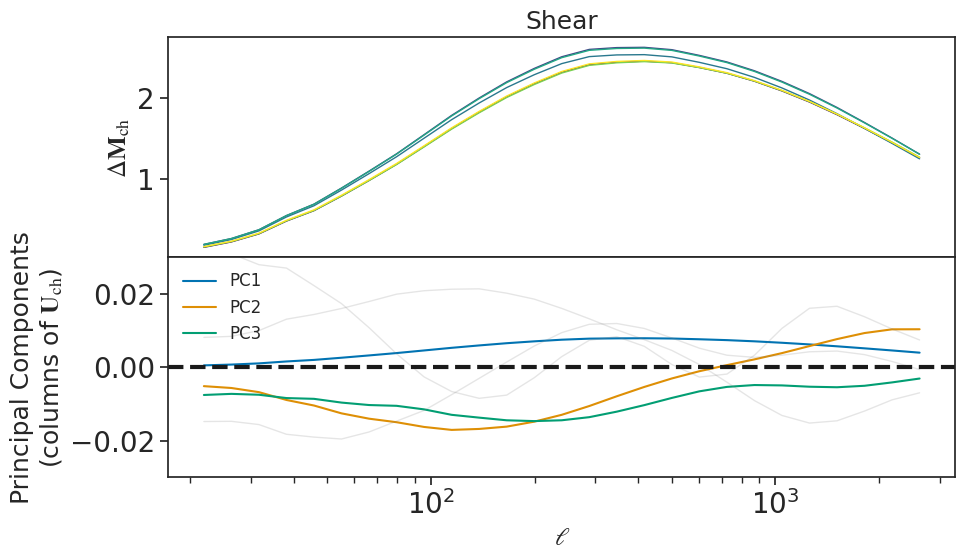

6


In [27]:
col = sns.color_palette("colorblind", len(pc_indices[0]))
# Create a 2x3 grid of subplots
fig, axs = plt.subplots(2, sharex=True, figsize=(10, 6))

# Generate the new log-spaced x-axis

# list 27 colors out of viridis color map, for the 27 combinations of q1q2q3 values
viridis = plt.cm.get_cmap('viridis', len(Model_q1q2q3_values_list))
colors1 = [viridis(i) for i in range(len(Model_q1q2q3_values_list))]

labels1 = [r'q1,q2,q3=({:.1f}, {:.1f}, {:.1f})'.format(q1, q2, q3) for q1, q2, q3 in Model_q1q2q3_values_list]
markers1 = ['o','D','P']
# list 27 colors out of colorblind color map, for the 27 combinations of q1q2q3 values

colors2 = [
    col[i] if i in (pc_indices[0]) else (0.5, 0.5, 0.5, 1.0)
    for i in range(len(Model_q1q2q3_values_list))
]
labels2 = ['PC{}'.format(i+1) if i in (pc_indices[0]) else None
    for i in range(len(Model_q1q2q3_values_list))
]

markers2 = ['x','.','^']
l_wl_max, l_gc_max = MGL_mu_lin.Survey.ells_wl_max, MGL_mu_lin.Survey.ells_gc_max
l_wl, l_gc, l_xc = MGL_mu_lin.Survey.l_wl, MGL_mu_lin.Survey.l_gc, MGL_mu_lin.Survey.l_xc

# Interpolate and plot on each subplot
for i in range(len(Model_q1q2q3_values_list)):
    # Scatter points
    axs[0].plot(l_wl[:ells_wl_bins[0]], Delta[i][:ells_wl_bins[0]], color=colors1[i],  linewidth=1)
axs[0].set_title('Shear', fontsize=18)

for i in range(len(Model_q1q2q3_values_list)):
    if i in pc_indices[0]:
        # Scatter points
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1.5)
    else:
        axs[1].plot(l_wl[:ells_wl_bins[0]], -Usvd[i][:ells_wl_bins[0]], color=colors2[i], label=labels2[i], linewidth=1, alpha=0.2)

# Plot horizontal lines at y=0
axs[1].axhline(y=0, linestyle="--", color="k")

# Add labels and set x-axis limits and scale
axs[1].set_xlabel(r'$\ell$', fontsize=18)
axs[0].legend(fontsize=12, frameon=False)
axs[1].legend(fontsize=12, frameon=False)
axs[0].set_ylabel(r'$\Delta \mathbf{M}_{\text{ch}}$', fontsize=18)
axs[1].set_ylabel('Principal Components' + '\n' + r'(columns of $\mathbf{U}_{\text{ch}}$)', fontsize=18)
# Add x-axis label shared across all subplots
for ax in axs.flat:
    ax.set_xscale("log")
# Adjust layout to prevent overlap
plt.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
axs[1].set_ylim(-0.03, 0.03)

# Display the plot
plt.show()
print(len(Model_q1q2q3_values_list))

## Quantitative measure of difference between PCs - linear

In [ ]:
MGL_mu_lin = MGLensing.MGL("ini_files/pca/config_muSigma_lin_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_lin.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_lin.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_lin.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_lin.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_q1q2q3_nl = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3.yaml")
MGL_q1q2q3_linear = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3_lin.yaml")

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_lin.Data.data_covariance
D_data = MGL_mu_lin.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_lin.params_fixed
param_dic_all, status = MGL_mu_lin.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_lin.Like.compute_data_vector(param_dic_all) 
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

# define params for analysis below
param_dic_all["mu0"] = 0.2
param_dic_all["Sigma0"] = 0.0

# Perform PCA with numpy.linalg.svd - find rotation matrix
def findPCA_and_explainedvariance(M_data, B_data, L_ch_inv):
    Delta = np.array(np.matmul(L_ch_inv, (B_data - M_data).T).T)
    Usvd, s, vh = np.linalg.svd(Delta.T, full_matrices=True)
    Usvd = Usvd.T
    # Calculate explained variance, variance_i = s_i/sum(s)
    explained_variance = s / np.sum(s)
    return Usvd, Delta, explained_variance

def get_Usvd_and_Delta(Model_q1q2q3_values_list):


    param_dic_list = []
    for q1q2q3 in Model_q1q2q3_values_list:
        param_dic_list.append(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})
        _, status = MGL_q1q2q3_nl.Like.Theo.check_pars(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})

    ### COMBINE
    # 1: find C_ell for non-linear matter power spectrum
    B_data  = np.array([MGL_q1q2q3_nl.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])
    # 2: find C_ell for linear matter power spectrum
    M_data  = np.array([MGL_q1q2q3_linear.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])

    Usvd, Delta, explained_variance = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)

    # keep PCs that explain more than 99.9% variance
    pc_indices = np.where(explained_variance > 0.001)
    print(pc_indices)

    return Usvd, Delta, explained_variance, pc_indices

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [ ]:
# find and plot difference in PCs compared to large range of q1q2q3 values, for a series of examples

# find large range of q1q2q3 values
q1_arr = np.linspace(-2,2, 5)
q2_arr = np.linspace(-2,2, 5)
q3_arr = np.linspace(-2,2, 5)

# find all combinations of q1q2q3 values in the ranges above, and store in list
Model_q1q2q3_values_list_base = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

# find additional examples
q1_arr = np.linspace(-2,2, 4)
q2_arr = np.linspace(-2,2, 4)
q3_arr = np.linspace(-2,2, 4)

Model_q1q2q3_values_list_1 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]
q1_arr = np.linspace(-2,2, 3)
q2_arr = np.linspace(-2,2, 3)
q3_arr = np.linspace(-2,2, 3)

Model_q1q2q3_values_list_2 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

q1_arr = np.linspace(-2,2, 2)
q2_arr = np.linspace(-2,2, 2)
q3_arr = np.linspace(-2,2, 2)

Model_q1q2q3_values_list_3 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

Model_q1q2q3_values_list_4 = [(-2,0,0), (0,-2,0), (0,0,-2), (2,0,0), (0,2,0), (0,0,2)]


In [ ]:
Usvd_base, Delta_base, explained_variance_base, pc_indices_base = get_Usvd_and_Delta(Model_q1q2q3_values_list_base)
Usvd_1, Delta_1, explained_variance_1, pc_indices_1 = get_Usvd_and_Delta(Model_q1q2q3_values_list_1)
Usvd_2, Delta_2, explained_variance_2, pc_indices_2 = get_Usvd_and_Delta(Model_q1q2q3_values_list_2)
Usvd_3, Delta_3, explained_variance_3, pc_indices_3 = get_Usvd_and_Delta(Model_q1q2q3_values_list_3)
Usvd_4, Delta_4, explained_variance_4, pc_indices_4 = get_Usvd_and_Delta(Model_q1q2q3_values_list_4)


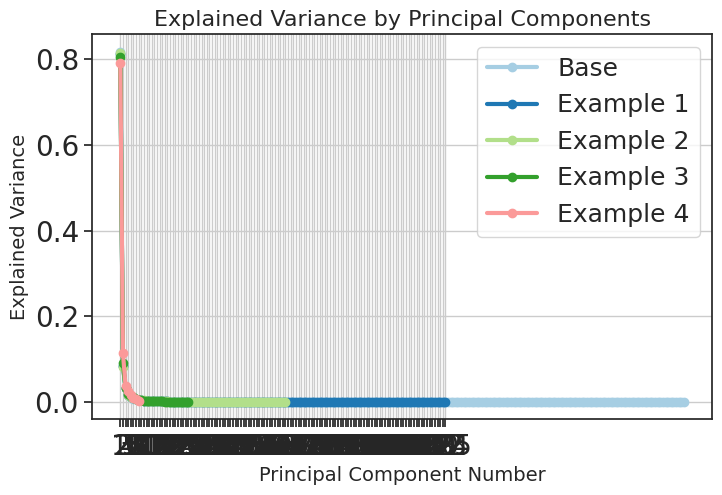

In [ ]:

#  plot of explained variance vs principal component number for all examples
plt.figure(figsize=(8, 5))

for explained_variance, label in zip([explained_variance_base, explained_variance_1, explained_variance_2, explained_variance_3, explained_variance_4],
                                   ['Base', 'Example 1', 'Example 2', 'Example 3', 'Example 4']):
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label=label)

plt.xlabel('Principal Component Number', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Explained Variance by Principal Components', fontsize=16)
plt.xticks(range(1, len(explained_variance_1) + 1))
plt.xlim(0, 10)
plt.grid()
plt.legend()
plt.show()



Number of PCs that explain more than 99.9% variance is the same for all examples:  3


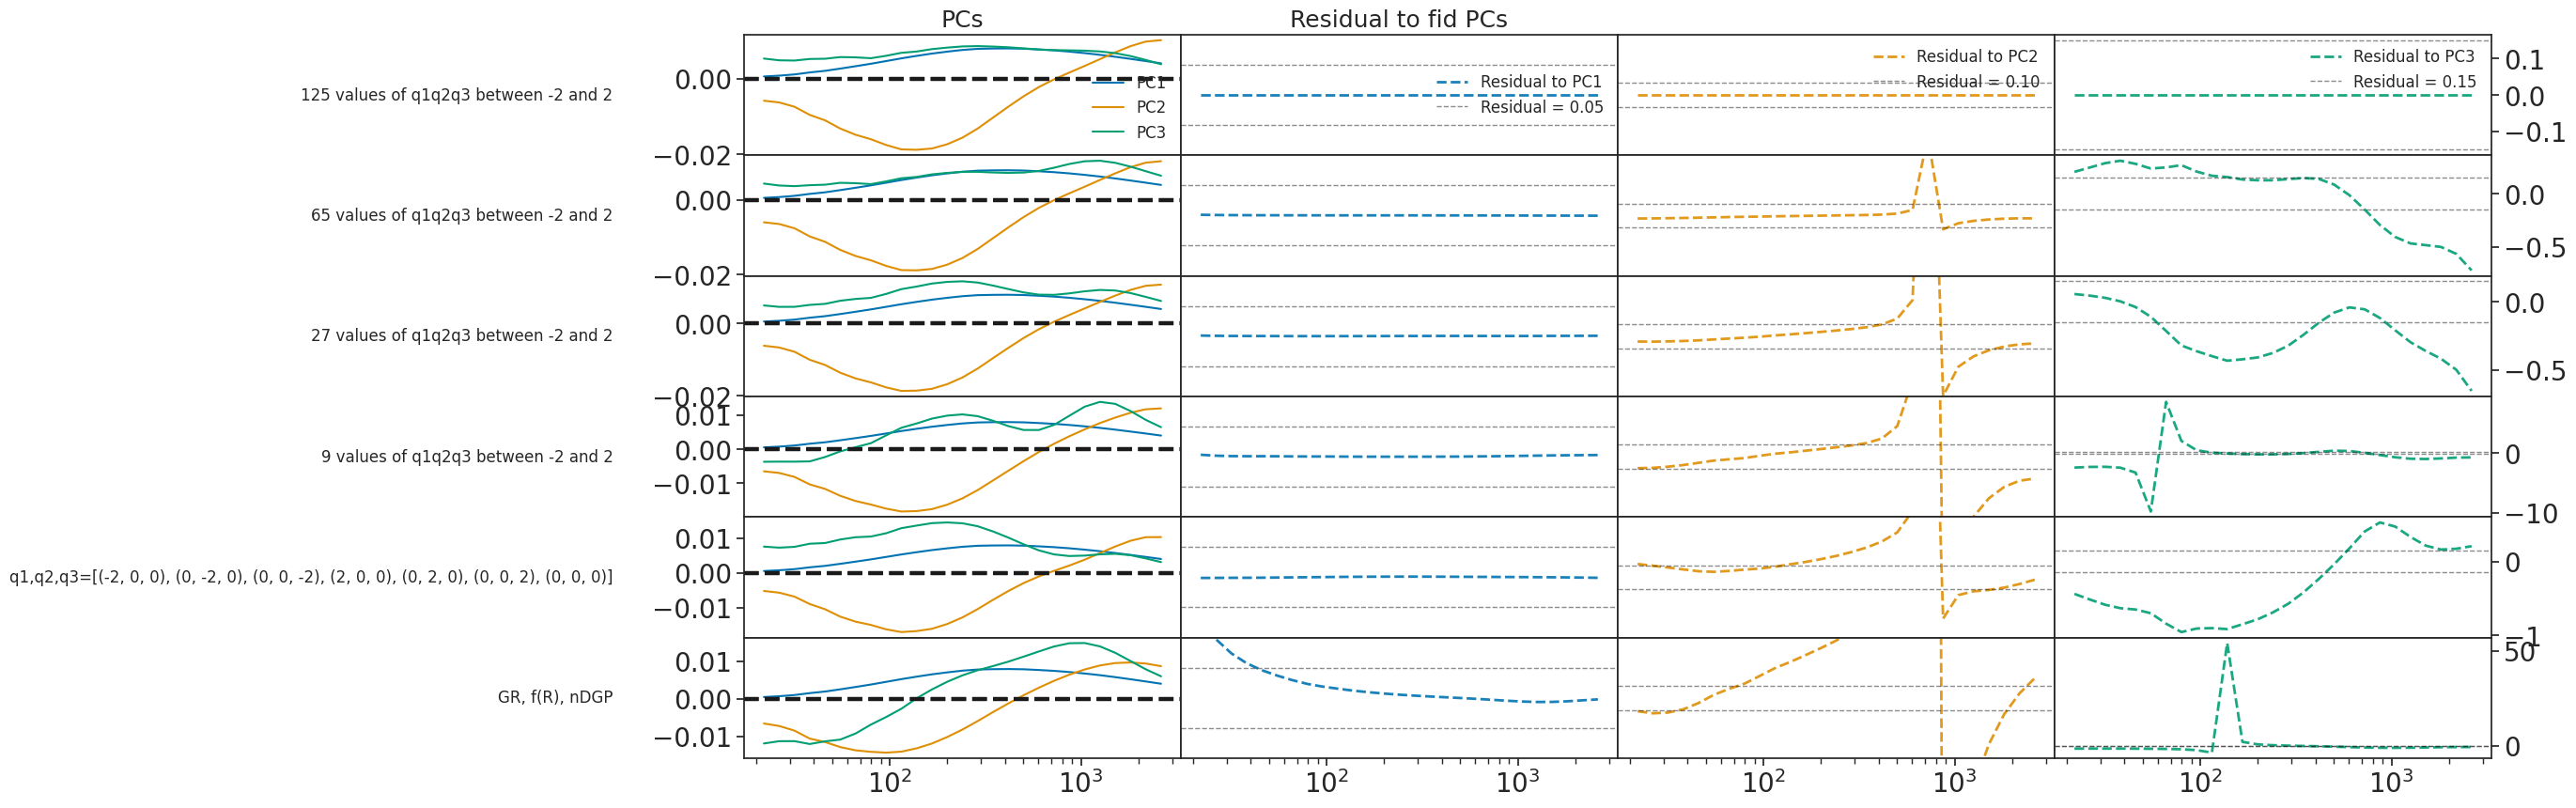

In [ ]:
# Plot PCs for each of the examples above, and residual to PCs from large range of q1q2q3 values

# check that the number of PCs that explain more than 99.9% variance is the same for all examples
try:
    assert len(pc_indices_base[0]) == len(pc_indices_1[0]) == len(pc_indices_2[0]) == len(pc_indices_3[0]) == len(pc_indices_4[0])
    print("Number of PCs that explain more than 99.9% variance is the same for all examples: ", len(pc_indices_base[0]))
except AssertionError:
    print("Number of PCs that explain more than 99.9% variance is not the same for all examples")

# plot the PCs for each example, and the residual to the PCs from the large range of q1q2q3 values

Usvd_list = [Usvd_base, Usvd_1, Usvd_2, Usvd_3, Usvd_4, Usvd_GRfRnDGP]
Delta_list = [Delta_base, Delta_1, Delta_2, Delta_3, Delta_4, Delta_GRfRnDGP]
explained_variance_list = [explained_variance_base, explained_variance_1, explained_variance_2, explained_variance_3, explained_variance_4, explained_variance_GRfRnDGP]
pc_indices_list = [pc_indices_base, pc_indices_1, pc_indices_2, pc_indices_3, pc_indices_4, pc_indices_4]

fig, axs = plt.subplots(len(Usvd_list), 4, sharex=True,figsize=(24, 10))
col = sns.color_palette("colorblind", len(pc_indices_base[0]))
labels = ['PC{}'.format(i+1) for i in range(len(pc_indices_base[0]))]

descriptions = [
    '{} data reduction theories'.format(len(Model_q1q2q3_values_list_base)),
    '{} data reduction theories'.format(len(Model_q1q2q3_values_list_1)),
    '{} data reduction theories'.format(len(Model_q1q2q3_values_list_2)),
    '{} data reduction theories'.format(len(Model_q1q2q3_values_list_3)),
    '{} data reduction theories'.format(len(Model_q1q2q3_values_list_4)),
    'Data reduction theories: GR, f(R), nDGP'
]

for i in range(len(Usvd_list)):
    Usvd, Delta, explained_variance, pc_indices = Usvd_list[i], Delta_list[i], explained_variance_list[i], pc_indices_list[i]
    for j in range(len(pc_indices[0])):
        # find sign for Usvd[j] that minimizes the difference to Usvd_base[j]
        if np.sum((Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2) > np.sum((-Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2):
            Usvd[j] = -Usvd[j]
            
        axs[i, 0].plot(l_wl[:ells_wl_bins[0]], -Usvd[j][:ells_wl_bins[0]], color=col[j], label=labels[j], linewidth=1.5)
        axs[i, 0].axhline(y=0, linestyle="--", color="k")
        
    # plot residual to PCs from large range of q1q2q3 values
        axs[i, j+1].plot(l_wl[:ells_wl_bins[0]], (Usvd_base[j][:ells_wl_bins[0]]-Usvd[j][:ells_wl_bins[0]]) / np.maximum(Usvd[j][:ells_wl_bins[0]], Usvd_base[j][:ells_wl_bins[0]]), color=col[j], label='Residual to ' + labels[j], linewidth=2, alpha=00.9, linestyle='--')
        # plot black dashed lines at 0.05 and -0.05
        axs[i, j+1].axhline(y=0.05*(j+1), linestyle="--", color="k", alpha=0.5, linewidth=1, label='Residual = {:.2f}'.format(0.05*(j+1)))
        axs[i, j+1].axhline(y=-0.05*(j+1), linestyle="--", color="k", alpha=0.5, linewidth=1)
        # set y-axis limits to -0.1 and 0.1
        axs[i, 1].set_ylim(-0.1, 0.1)
        axs[i, 2].set_ylim(-0.5, 0.5)
    for ax in axs.flat:
        ax.set_xscale("log")
    # set axs[i, 3] to the right of the plot
    axs[i, 3].yaxis.tick_right()
    # remove ticks from axs[i, 1] and axs[i, 2]
    axs[i, 1].tick_params(left=False, labelleft=False)
    axs[i, 2].tick_params(left=False, labelleft=False)
    # at the rhs of each plot, add example number description
    axs[i, 1].text(-1.3, 0.5, descriptions[i], transform=axs[i, 1].transAxes, fontsize=12, verticalalignment='center', horizontalalignment='right')

    

axs[0, 0].set_title('PCs', fontsize=18)
axs[0, 1].set_title('Residual to fid PCs', fontsize=18)
axs[0, 0].legend(fontsize=12, frameon=False)
axs[0, 1].legend(fontsize=12, frameon=False)
axs[0, 2].legend(fontsize=12, frameon=False)
axs[0, 3].legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.show()

## Quantitative measure of difference between PCs - pseudo

In [32]:
MGL_mu_pseudo = MGLensing.MGL("ini_files/pca/config_muSigma_pseudo_PCA.yaml")

ells_wl_bins = []
ells_gc_bins = []
ells_xc_bins = []
#print(MGL_mu_pseudo.Survey.masked_data_vector_3x2pt_ells)
for i in range(MGL_mu_pseudo.Survey.mask_ells_wl.shape[0]):
    #print('bin ', i, ' number of ells_wl: ', sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))
    ells_wl_bins.append(sum(MGL_mu_pseudo.Survey.mask_ells_wl[i]))

ells_wl_bins = np.array(ells_wl_bins)
ells_gc_bins = np.array(ells_gc_bins)
ells_xc_bins = np.array(ells_xc_bins)

#MGL_GR_nl = MGLensing.MGL("ini_files/pca/config_GR.yaml")
#MGL_GR_lin = MGLensing.MGL("ini_files/pca/config_GR_pseudo.yaml")
MGL_q1q2q3_nl = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3.yaml")
MGL_q1q2q3_pseudo = MGLensing.MGL("ini_files/pca/config_muSigma_q1q2q3_pseudo.yaml")

# [r"$\Omega_m$", r"$w_b$",r"$h$",r"$log10As$",r"$n_s$", r"$\mu_0$",r"$a1_{IA}$",r"$\eta 1_{IA}$"]
# [ 0.31892037  0.0226738   0.67567714  3.02769177  0.95492059 -4.98800875, 1.7180302  -0.4060574  -8.00399565]
pars = {
    "Omega_m": 0.31892037,
    "Ombh2": 0.0226738,
    "h": 0.67567714,
    "log10As": 3.02769177,
    "ns": 0.95492059,
    "log10f_R0": -4.98800875,
    "a1_IA": 1.7180302,
    "eta1_IA": -0.4060574}

print("Parameters: ", pars)
cov = MGL_mu_pseudo.Data.data_covariance
D_data = MGL_mu_pseudo.Data.data_vector

L_choleski_uncut = np.linalg.cholesky(np.matrix(cov))
L_choleski_inv_uncut = np.linalg.inv(L_choleski_uncut)

L_ch_inv = L_choleski_inv_uncut

param_dic = pars | MGL_mu_pseudo.params_fixed
param_dic_all, status = MGL_mu_pseudo.Like.Theo.check_pars(param_dic)

if status:
    D_theory = MGL_mu_pseudo.Like.compute_data_vector(param_dic_all)
else:
    D_theory = -np.inf

Diff = (D_data - D_theory)

# Find Choleski scaled data vector
Diff_ch = np.array(np.matmul(L_ch_inv, Diff.T))[0]

# define params for analysis below
param_dic_all["mu0"] = 0.2
param_dic_all["Sigma0"] = 0.0

# Perform PCA with numpy.linalg.svd - find rotation matrix
def findPCA_and_explainedvariance(M_data, B_data, L_ch_inv):
    Delta = np.array(np.matmul(L_ch_inv, (B_data - M_data).T).T)
    Usvd, s, vh = np.linalg.svd(Delta.T, full_matrices=True)
    Usvd = Usvd.T
    # Calculate explained variance, variance_i = s_i/sum(s)
    explained_variance = s / np.sum(s)
    return Usvd, Delta, explained_variance

def get_Usvd_and_Delta(Model_q1q2q3_values_list):


    param_dic_list = []
    for q1q2q3 in Model_q1q2q3_values_list:
        param_dic_list.append(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})
        _, status = MGL_q1q2q3_nl.Like.Theo.check_pars(param_dic_all | {"q1": q1q2q3[0], "q2": q1q2q3[1], "q3": q1q2q3[2]})

    ### COMBINE
    # 1: find C_ell for non-linear matter power spectrum
    B_data  = np.array([MGL_q1q2q3_nl.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])
    # 2: find C_ell for linear matter power spectrum
    M_data  = np.array([MGL_q1q2q3_pseudo.Like.compute_data_vector(param_dic) for param_dic in param_dic_list])

    Usvd, Delta, explained_variance = findPCA_and_explainedvariance(M_data, B_data, L_ch_inv)

    # keep PCs that explain more than 99.9% variance
    pc_indices = np.where(explained_variance > 0.001)
    print(pc_indices)

    return Usvd, Delta, explained_variance, pc_indices

Lens galaxy distribution for bin  0  integrates to  0.9999124337480232
Lens galaxy distribution for bin  1  integrates to  0.9999897457955874
Lens galaxy distribution for bin  2  integrates to  1.000022273457735
Lens galaxy distribution for bin  3  integrates to  1.0000013871027367
Lens galaxy distribution for bin  4  integrates to  0.9999975227323131
Source galaxy distribution for bin  0  integrates to  0.9999221860880855
Source galaxy distribution for bin  1  integrates to  0.9999984954842106
Source galaxy distribution for bin  2  integrates to  1.0000000107297902
Source galaxy distribution for bin  3  integrates to  1.000000047974446
Source galaxy distribution for bin  4  integrates to  0.9922060415108314
path:  ./
model["nl_model"] =  6
initialising f(R) ReACT
initialising hmcode
################################
checking parameters for data....
all good with the data dictionary
################################
start computing mock data
computing data vector
wl_masked_ells:  405
gc_

In [33]:
# find and plot difference in PCs compared to large range of q1q2q3 values, for a series of examples


# find large range of q1q2q3 values
q1_arr = np.linspace(-2,2, 6)
q2_arr = np.linspace(-2,2, 6)
q3_arr = np.linspace(-2,2, 6)

# find all combinations of q1q2q3 values in the ranges above, and store in list
Model_q1q2q3_values_list_base = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

# find additional examples
q1_arr = np.linspace(-2,2, 5)
q2_arr = np.linspace(-2,2, 5)
q3_arr = np.linspace(-2,2, 5)

Model_q1q2q3_values_list_1 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]
q1_arr = np.linspace(-2,2, 4)
q2_arr = np.linspace(-2,2, 4)
q3_arr = np.linspace(-2,2, 4)

Model_q1q2q3_values_list_2 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

q1_arr = np.linspace(-2,2, 3)
q2_arr = np.linspace(-2,2, 3)
q3_arr = np.linspace(-2,2, 3)

Model_q1q2q3_values_list_3 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

q1_arr = np.linspace(-2,2, 2)
q2_arr = np.linspace(-2,2, 2)
q3_arr = np.linspace(-2,2, 2)

Model_q1q2q3_values_list_4 = [
    (q1, q2, q3)
    for q1 in q1_arr
    for q2 in q2_arr
    for q3 in q3_arr
]

Model_q1q2q3_values_list_5 = [(-2,0,0), (0,-2,0), (0,0,-2), (2,0,0), (0,2,0), (0,0,2)]


In [34]:
Usvd_base, Delta_base, explained_variance_base, pc_indices_base = get_Usvd_and_Delta(Model_q1q2q3_values_list_base)
Usvd_1, Delta_1, explained_variance_1, pc_indices_1 = get_Usvd_and_Delta(Model_q1q2q3_values_list_1)
Usvd_2, Delta_2, explained_variance_2, pc_indices_2 = get_Usvd_and_Delta(Model_q1q2q3_values_list_2)
Usvd_3, Delta_3, explained_variance_3, pc_indices_3 = get_Usvd_and_Delta(Model_q1q2q3_values_list_3)
Usvd_4, Delta_4, explained_variance_4, pc_indices_4 = get_Usvd_and_Delta(Model_q1q2q3_values_list_4)
Usvd_5, Delta_5, explained_variance_5, pc_indices_5 = get_Usvd_and_Delta(Model_q1q2q3_values_list_5)

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15]),)
(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13]),)
(array([0, 1, 2, 3, 4, 5, 6, 7]),)
(array([0, 1, 2, 3, 4, 5]),)


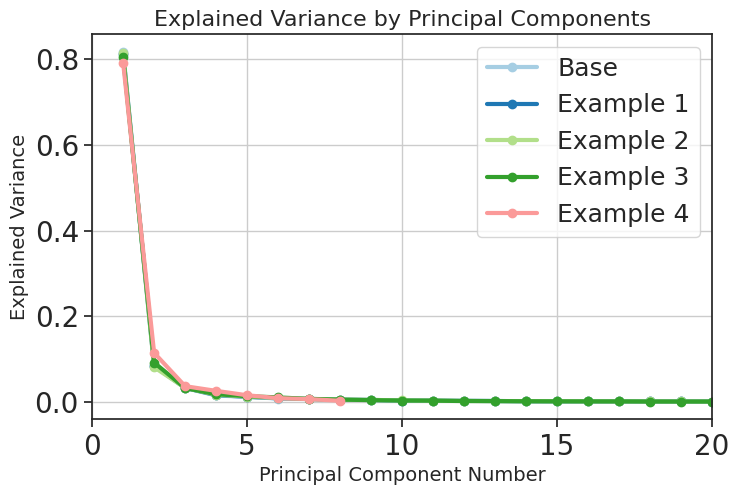

In [43]:

#  plot of explained variance vs principal component number for all examples
plt.figure(figsize=(8, 5))

for explained_variance, label in zip([explained_variance_base, explained_variance_1, explained_variance_2, explained_variance_3, explained_variance_4],
                                   ['Base', 'Example 1', 'Example 2', 'Example 3', 'Example 4']):
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label=label)

plt.xlabel('Principal Component Number', fontsize=14)
plt.ylabel('Explained Variance', fontsize=14)
plt.title('Explained Variance by Principal Components', fontsize=16)
#plt.xticks(range(1, len(explained_variance_1) + 1))
plt.xlim(0,20)

plt.grid()
plt.legend()
plt.show()



Number of PCs that explain more than 99.9% variance is not the same for all examples: 15 16 16 14 8 6
2


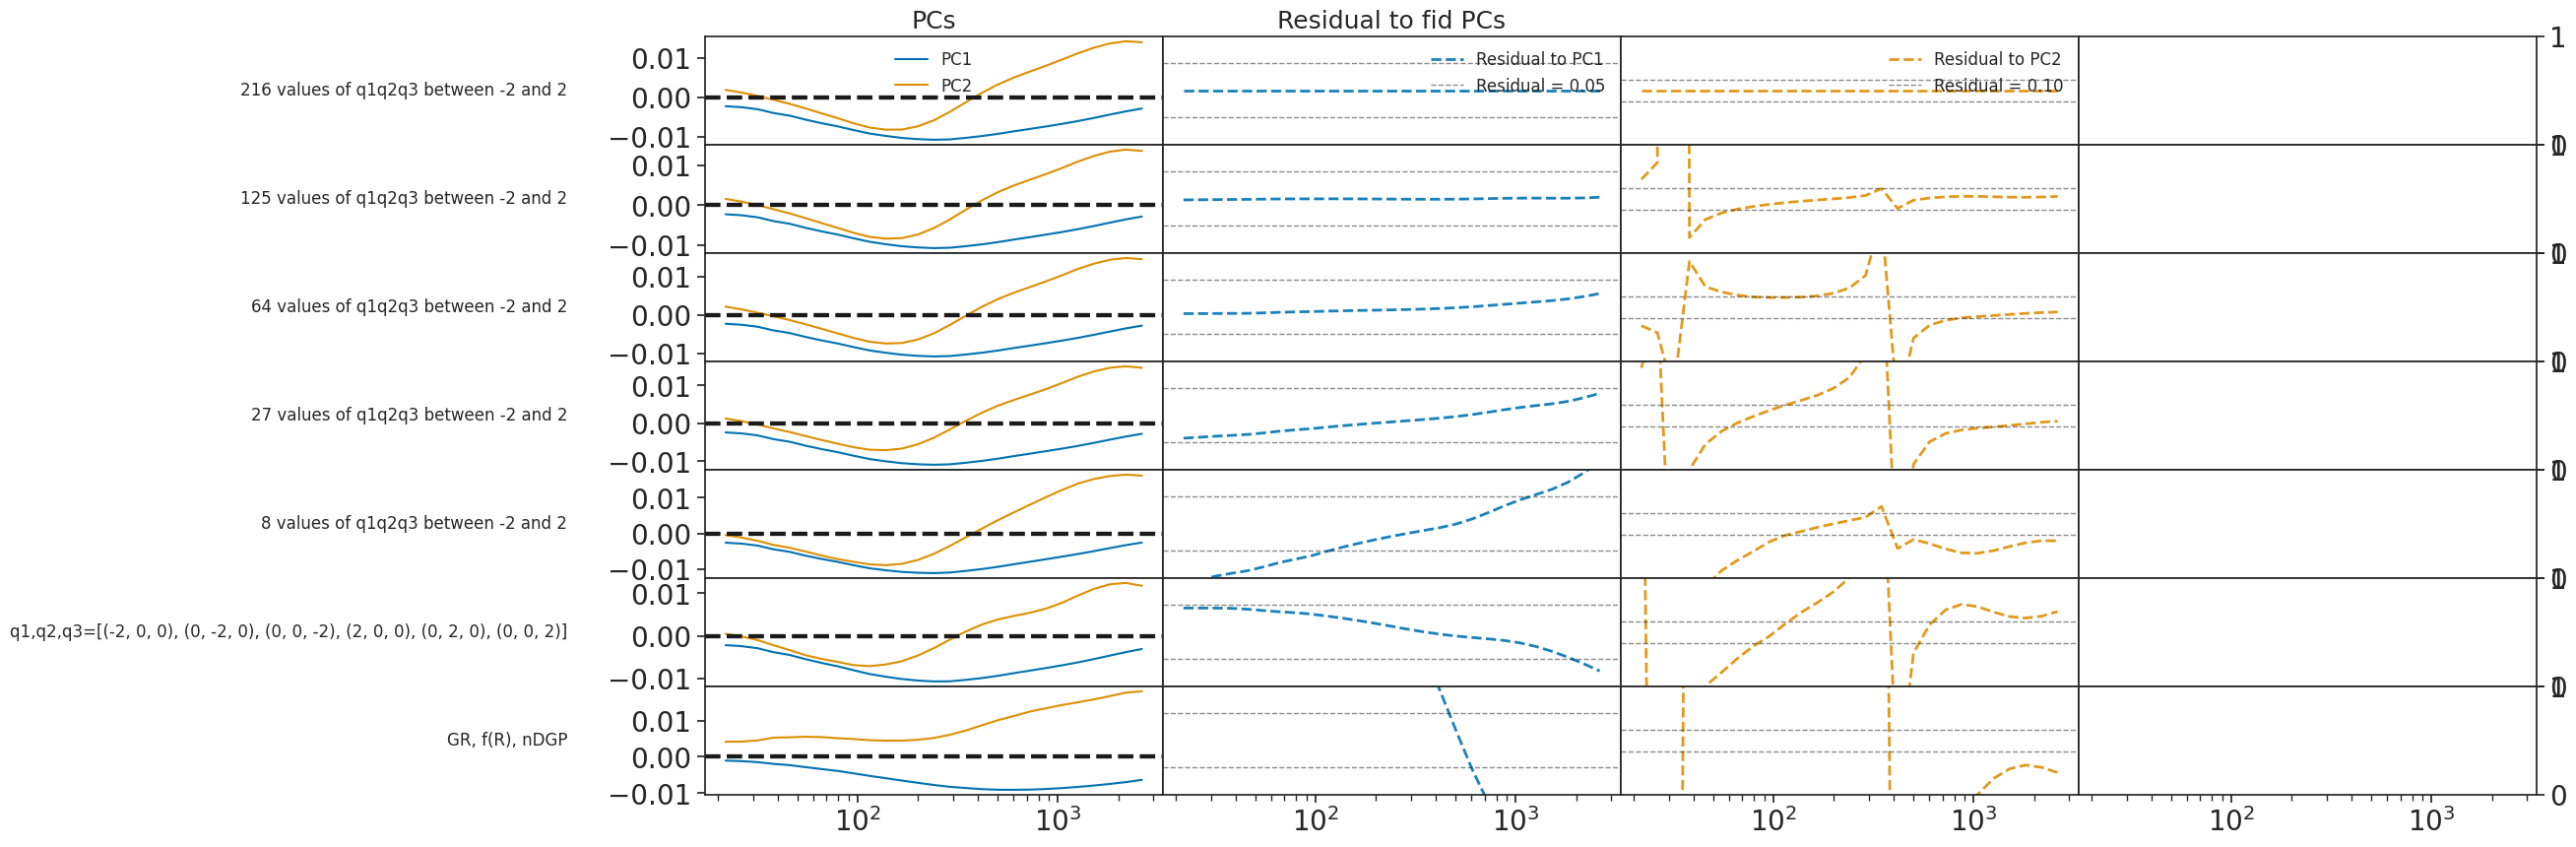

In [35]:
# Plot PCs for each of the examples above, and residual to PCs from large range of q1q2q3 values

# check that the number of PCs that explain more than 99.9% variance is the same for all examples
try:
    assert len(pc_indices_base[0]) == len(pc_indices_1[0]) == len(pc_indices_2[0]) == len(pc_indices_3[0]) == len(pc_indices_4[0]) == len(pc_indices_5[0])
    print("Number of PCs that explain more than 99.9% variance is the same for all examples: ", len(pc_indices_base[0]))
    pc_indices_list = [pc_indices_base, pc_indices_1, pc_indices_2, pc_indices_3, pc_indices_4, pc_indices_5, pc_indices_5]
    pc_indices_min = len(pc_indices_base[0])

except AssertionError:
    print("Number of PCs that explain more than 99.9% variance is not the same for all examples:", len(pc_indices_base[0]), len(pc_indices_1[0]), len(pc_indices_2[0]), len(pc_indices_3[0]), len(pc_indices_4[0]), len(pc_indices_5[0]))
    pc_indices_min = np.min([len(pc_indices_base[0]), len(pc_indices_1[0]), len(pc_indices_2[0]), len(pc_indices_3[0]), len(pc_indices_4[0]), len(pc_indices_5[0]), 2])
    pc_indices_list = [pc_indices_base[:pc_indices_min], pc_indices_1[:pc_indices_min], pc_indices_2[:pc_indices_min], pc_indices_3[:pc_indices_min], pc_indices_4[:pc_indices_min],pc_indices_5[:pc_indices_min], pc_indices_5[:pc_indices_min]]
    print(pc_indices_min)
# plot the PCs for each example, and the residual to the PCs from the large range of q1q2q3 values

Usvd_list = [Usvd_base, Usvd_1, Usvd_2, Usvd_3, Usvd_4, Usvd_5, Usvd_GRfRnDGP_pseudo]
Delta_list = [Delta_base, Delta_1, Delta_2, Delta_3, Delta_4,Delta_5, Delta_GRfRnDGP_pseudo]
explained_variance_list = [explained_variance_base, explained_variance_1, explained_variance_2, explained_variance_3, explained_variance_4, explained_variance_5, explained_variance_GRfRnDGP_pseudo]

fig, axs = plt.subplots(len(Usvd_list), 4, sharex=True,figsize=(24, 10))
col = sns.color_palette("colorblind", len(pc_indices_base[0]))
labels = ['PC{}'.format(i+1) for i in range(len(pc_indices_base[0]))]

descriptions = [
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_base)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_1)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_2)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_3)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_4)),
    'q1,q2,q3={}'.format(Model_q1q2q3_values_list_5),
    'GR, f(R), nDGP'
]

for i in range(len(Usvd_list)):
    Usvd, Delta, explained_variance, pc_indices = Usvd_list[i], Delta_list[i], explained_variance_list[i], pc_indices_list[i]
    for j in range(pc_indices_min):

        # find sign for Usvd[j] that minimizes the difference to Usvd_base[j]
        if np.sum((Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2) > np.sum((-Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2):
            Usvd[j] = -Usvd[j]

        axs[i, 0].plot(l_wl[:ells_wl_bins[0]], -Usvd[j][:ells_wl_bins[0]], color=col[j], label=labels[j], linewidth=1.5)
        axs[i, 0].axhline(y=0, linestyle="--", color="k")
    # plot residual to PCs from large range of q1q2q3 values
        axs[i, j+1].plot(l_wl[:ells_wl_bins[0]], (Usvd_base[j][:ells_wl_bins[0]]-Usvd[j][:ells_wl_bins[0]]) / np.maximum(Usvd[j][:ells_wl_bins[0]], Usvd_base[j][:ells_wl_bins[0]]), color=col[j], label='Residual to ' + labels[j], linewidth=2, alpha=00.9, linestyle='--')
        # plot black dashed lines at 0.05 and -0.05
        axs[i, j+1].axhline(y=0.05*(j+1), linestyle="--", color="k", alpha=0.5, linewidth=1, label='Residual = {:.2f}'.format(0.05*(j+1)))
        axs[i, j+1].axhline(y=-0.05*(j+1), linestyle="--", color="k", alpha=0.5, linewidth=1)
        # set y-axis limits to -0.1 and 0.1
        axs[i, 1].set_ylim(-0.1, 0.1)
        axs[i, 2].set_ylim(-0.5, 0.5)
    for ax in axs.flat:
        ax.set_xscale("log")
    # set axs[i, 3] to the right of the plot
    axs[i, 3].yaxis.tick_right()
    # remove ticks from axs[i, 1] and axs[i, 2]
    axs[i, 1].tick_params(left=False, labelleft=False)
    axs[i, 2].tick_params(left=False, labelleft=False)
    # at the rhs of each plot, add example number description
    axs[i, 1].text(-1.3, 0.5, descriptions[i], transform=axs[i, 1].transAxes, fontsize=12, verticalalignment='center', horizontalalignment='right')

    

axs[0, 0].set_title('PCs', fontsize=18)
axs[0, 1].set_title('Residual to fid PCs', fontsize=18)
axs[0, 0].legend(fontsize=12, frameon=False)
axs[0, 1].legend(fontsize=12, frameon=False)
axs[0, 2].legend(fontsize=12, frameon=False)
axs[0, 3].legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.show()

Number of PCs that explain more than 99.9% variance is not the same for all examples: 15 16 16 14 8 6
6


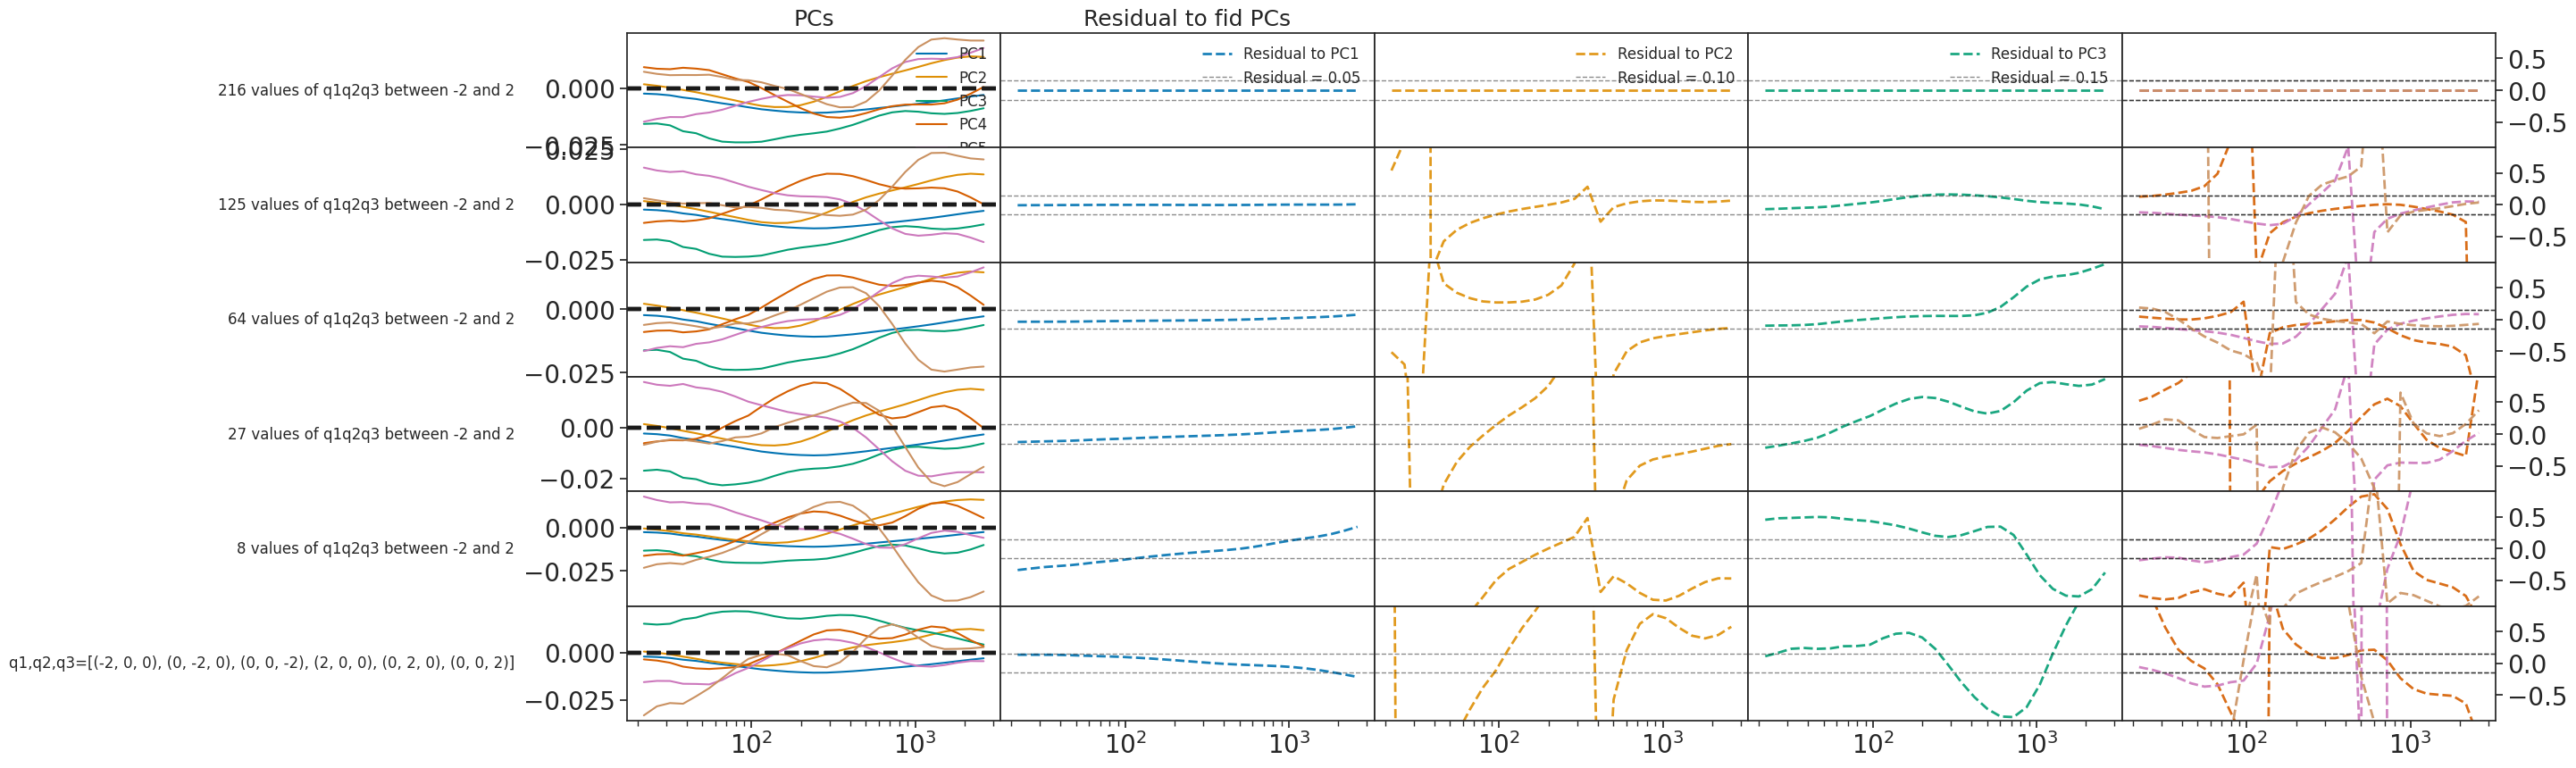

In [36]:
# Plot PCs for each of the examples above, and residual to PCs from large range of q1q2q3 values

# check that the number of PCs that explain more than 99.9% variance is the same for all examples
try:
    assert len(pc_indices_base[0]) == len(pc_indices_1[0]) == len(pc_indices_2[0]) == len(pc_indices_3[0]) == len(pc_indices_4[0])
    print("Number of PCs that explain more than 99.9% variance is the same for all examples: ", len(pc_indices_base[0]))
    pc_indices_list = [pc_indices_base, pc_indices_1, pc_indices_2, pc_indices_3, pc_indices_4, pc_indices_4]
    pc_indices_min = len(pc_indices_base[0])

except AssertionError:
    print("Number of PCs that explain more than 99.9% variance is not the same for all examples:", len(pc_indices_base[0]), len(pc_indices_1[0]), len(pc_indices_2[0]), len(pc_indices_3[0]), len(pc_indices_4[0]), len(pc_indices_5[0]))
    pc_indices_min = np.min([len(pc_indices_base[0]), len(pc_indices_1[0]), len(pc_indices_2[0]), len(pc_indices_3[0]), len(pc_indices_4[0]), len(pc_indices_5[0])])
    pc_indices_list = [pc_indices_base[:pc_indices_min], pc_indices_1[:pc_indices_min], pc_indices_2[:pc_indices_min], pc_indices_3[:pc_indices_min], pc_indices_4[:pc_indices_min], pc_indices_5[:pc_indices_min]]
    print(pc_indices_min)
# plot the PCs for each example, and the residual to the PCs from the large range of q1q2q3 values

Usvd_list = [Usvd_base, Usvd_1, Usvd_2, Usvd_3, Usvd_4, Usvd_5]
Delta_list = [Delta_base, Delta_1, Delta_2, Delta_3, Delta_4, Delta_5]
explained_variance_list = [explained_variance_base, explained_variance_1, explained_variance_2, explained_variance_3, explained_variance_4, explained_variance_5]

fig, axs = plt.subplots(len(Usvd_list), 5, sharex=True,figsize=(27, 10))
col = sns.color_palette("colorblind", len(pc_indices_base[0]))
labels = ['PC{}'.format(i+1) for i in range(len(pc_indices_base[0]))]


descriptions = [
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_base)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_1)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_2)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_3)),
    '{} values of q1q2q3 between -2 and 2'.format(len(Model_q1q2q3_values_list_4)),
    'q1,q2,q3={}'.format(Model_q1q2q3_values_list_5),
    'GR, f(R), nDGP'
]
for i in range(len(Usvd_list)):
    Usvd, Delta, explained_variance, pc_indices = Usvd_list[i], Delta_list[i], explained_variance_list[i], pc_indices_list[i]
    for j in range(pc_indices_min):
        axs[i, 0].plot(l_wl[:ells_wl_bins[0]], -Usvd[j][:ells_wl_bins[0]], color=col[j], label=labels[j], linewidth=1.5)
        axs[i, 0].axhline(y=0, linestyle="--", color="k")
        # find sign for Usvd[j] that minimizes the difference to Usvd_base[j]
        if np.sum((Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2) > np.sum((-Usvd[j][:ells_wl_bins[0]] - Usvd_base[j][:ells_wl_bins[0]])**2):
            Usvd[j] = -Usvd[j]
        # plot residual to PCs from large range of q1q2q3 values
        if j < 3:
            axs[i, j+1].plot(l_wl[:ells_wl_bins[0]], (Usvd_base[j][:ells_wl_bins[0]]-Usvd[j][:ells_wl_bins[0]]) / np.maximum(Usvd[j][:ells_wl_bins[0]], Usvd_base[j][:ells_wl_bins[0]]), color=col[j], label='Residual to ' + labels[j], linewidth=2, alpha=00.9, linestyle='--')
            # plot black dashed lines at 0.05 and -0.05
            axs[i, j+1].axhline(y=0.05, linestyle="--", color="k", alpha=0.5, linewidth=1, label='Residual = {:.2f}'.format(0.05*(j+1)))
            axs[i, j+1].axhline(y=-0.05, linestyle="--", color="k", alpha=0.5, linewidth=1)
        else:
            axs[i, 4].plot(l_wl[:ells_wl_bins[0]], (Usvd_base[j][:ells_wl_bins[0]]-Usvd[j][:ells_wl_bins[0]]) / np.maximum(Usvd[j][:ells_wl_bins[0]], Usvd_base[j][:ells_wl_bins[0]]), color=col[j], label='Residual to ' + labels[j], linewidth=2, alpha=00.9, linestyle='--')
            # plot black dashed lines at 0.05 and -0.05
            axs[i, 4].axhline(y=0.15, linestyle="--", color="k", alpha=0.5, linewidth=1)
            axs[i, 4].axhline(y=-0.15, linestyle="--", color="k", alpha=0.5, linewidth=1)
        # set y-axis limits to -0.1 and 0.1
        axs[i, 1].set_ylim(-0.3, 0.3)
        axs[i, 2].set_ylim(-0.3, 0.3)
        axs[i, 3].set_ylim(-0.3, 0.3)
        axs[i, 4].set_ylim(-0.9, 0.9)
    for ax in axs.flat:
        ax.set_xscale("log")
    # set axs[i, 3] to the right of the plot
    axs[i, 4].yaxis.tick_right()
    # remove ticks from axs[i, 1] and axs[i, 2]
    axs[i, 1].tick_params(left=False, labelleft=False)
    axs[i, 2].tick_params(left=False, labelleft=False)
    axs[i, 3].tick_params(left=False, labelleft=False)
    # at the rhs of each plot, add example number description
    axs[i, 1].text(-1.3, 0.5, descriptions[i], transform=axs[i, 1].transAxes, fontsize=12, verticalalignment='center', horizontalalignment='right')

    

axs[0, 0].set_title('PCs', fontsize=18)
axs[0, 1].set_title('Residual to fid PCs', fontsize=18)
axs[0, 0].legend(fontsize=12, frameon=False)
axs[0, 1].legend(fontsize=12, frameon=False)
axs[0, 2].legend(fontsize=12, frameon=False)
axs[0, 3].legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.subplots_adjust(wspace=0.0, hspace=0.0)
plt.show()